In [ ]:
# Title: 04_Smith_PCR.ipynb
# Author: Lajoyce Mboning
# Date:2025
# Related publication: Emma K. Costa, and Jingxun Chen, in prep


# Description - Run the PCR clock on Smith et al

# Set-Up

In [1]:
import os
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from scipy.stats import poisson
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso
from numpy import arange
from numpy import absolute
from numpy import mean
from numpy import std
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error
import statsmodels.api as sm
lowess = sm.nonparametric.lowess
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
#import umap
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
#from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from scipy.stats import ttest_ind, mannwhitneyu
import random
import itertools

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.chdir("/content/drive/My Drive/african_killifish_atlas/revisions/CodeCheck_revisions/Smith_model_outputs/PCR/")

In [4]:
palette = sns.color_palette("deep")
hex_codes = palette.as_hex()

print(hex_codes)

['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b3', '#937860', '#da8bc3', '#8c8c8c', '#ccb974', '#64b5cd']


In [5]:
# List of directories you want to create
dirs_to_create = [
    "./reference/",
    "./predictions/",
    "./gene_sets/",
    "./plots/",
    "./predictions_exhaustive/",
    "./reference_exhaustive/"
]


for d in dirs_to_create:
    os.makedirs(d, exist_ok=True)  # exist_ok=True won't raise an error if it already exists

### Load data

In [6]:
df_norm = pd.read_csv("../../AtlasFiles_forLajoyce_240507/CountsNormDESeq2_AllTissue_240506.csv")

In [7]:
df_norm = df_norm.T

In [8]:
df_norm.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,913.804009,178.356927,1117.483215,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791
A1_2,36.845369,407.384647,349.683408,374.015256,493.588906,469.257059,963.541161,1619.805848,453.962755,449.791581,...,774.447946,64.653195,670.168600,107.060129,777.923924,19.465478,672.254187,2691.797529,191.873997,253.746410
A10_1,4821.965545,907.596706,218.510659,554.051370,191.503723,684.175695,1125.288972,662.897504,586.787050,637.527352,...,520.497299,128.487541,1351.165159,112.938093,1122.015404,311.807344,542.593883,2612.307200,408.377598,391.191366
A10_2,4.382338,451.380822,1198.256441,303.633424,289.860362,445.120339,1093.080327,468.284126,709.312721,492.073962,...,1201.386683,131.470142,800.089724,174.667475,1304.058604,28.172173,1264.617561,1144.416288,157.764171,238.524401
A11_1,7011.583272,766.674115,222.103168,627.278822,272.285474,675.602523,1267.567871,975.767056,739.724358,713.703904,...,420.973787,192.365505,1129.101879,109.657631,1059.404232,398.670540,521.338398,1948.746206,360.569160,446.064940


In [9]:
df_norm_frequency = df_norm.div(df_norm.sum(axis=1), axis=0)

In [10]:
df_metadata = pd.read_csv("../../AtlasFiles_forLajoyce_240507/ExperimentDesign_allbatches_combined_v7.csv")

df_metadata.head(3)

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [11]:
df_metadata.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df_metadata.head(3)

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,sample,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [12]:
df_metadata.set_index("sample", inplace=True)

In [13]:
# Merge based on index
combined_df = pd.concat([df_norm_frequency, df_metadata[['sex', 'tissue', 'age_days']]], axis=1)

In [14]:
combined_df["tissue"].value_counts()

,count
tissue,
Gut,55
Kidney,55
Muscle,55
Spleen,55
Heart,54
SpinalCord,54
Brain,54
Skin,54
Liver,54


In [15]:
df_norm_metadata = pd.concat([df_norm, df_metadata[["sex", "tissue", "age_days"]]], axis=1)

df_norm_metadata.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791,F,Gut,155
A1_2,36.845369,407.384647,349.683408,374.015256,493.588906,469.257059,963.541161,1619.805848,453.962755,449.791581,...,107.060129,777.923924,19.465478,672.254187,2691.797529,191.873997,253.746410,M,Bone,78
A10_1,4821.965545,907.596706,218.510659,554.051370,191.503723,684.175695,1125.288972,662.897504,586.787050,637.527352,...,112.938093,1122.015404,311.807344,542.593883,2612.307200,408.377598,391.191366,M,Kidney,133
A10_2,4.382338,451.380822,1198.256441,303.633424,289.860362,445.120339,1093.080327,468.284126,709.312721,492.073962,...,174.667475,1304.058604,28.172173,1264.617561,1144.416288,157.764171,238.524401,M,SpinalCord,75
A11_1,7011.583272,766.674115,222.103168,627.278822,272.285474,675.602523,1267.567871,975.767056,739.724358,713.703904,...,109.657631,1059.404232,398.670540,521.338398,1948.746206,360.569160,446.064940,M,Kidney,47


In [16]:
#function to load norm counts
def load_intervention_countdata(tissue):
    file_path = f"../../Data_from_Others/Valenzano_Gut_Smith_etal_2017/CountsNormDESeq2_ValenzanoGut_250605.csv"
    return pd.read_csv(file_path)

#function to load metadata
def load_intervention_metadata(tissue):
    file_path = f"../../Data_from_Others/Valenzano_Gut_Smith_etal_2017/ExperimentDesign_ValenzanoGut_update_20250629.csv"
    return pd.read_csv(file_path)

In [17]:
select_tissue = 'Gut'

In [18]:
#load intervention data
df_intervention = load_intervention_countdata(select_tissue)
df_intervention.head(5)

,Unnamed: 0,D15.YM.16wk.3,D13.YM.16wk.1,C19.SM.16wk.1,C12.SM.16wk.6,C11.SM.16wk.5,C10.SM.16wk.2,B7.WT.16wk.6,B5.WT.16wk.1,A3.YI.6wk.3,A2.YI.6wk.1,D16.YM.16wk.8,D14.YM.16wk.4,B8.WT.16wk.7,B6.WT.16wk.2,A18.YI.6wk.4,A17.YI.6wk.2
0,cnot8,509.104136,598.130125,496.589632,538.920468,495.189776,503.026874,622.533378,619.841036,557.017265,603.016111,647.082047,520.354131,596.939392,601.223760,584.643093,555.497581
1,LOC107386976,195.809283,113.310365,74.117856,220.718280,245.245791,49.247386,208.413348,68.991002,163.006725,118.279868,162.654504,168.895431,161.612699,150.532646,45.189804,133.069356
2,LOC107379175,203.340409,168.108001,234.397718,313.603890,242.426873,233.338806,176.835568,190.803241,237.524085,454.110206,166.190471,232.353252,215.794991,181.364633,289.026457,435.824468
3,inhbb,237.983590,235.908465,213.088835,313.603890,218.935897,175.883522,140.746677,169.243553,191.882202,409.755256,199.192834,218.685413,142.929150,210.382975,223.124659,424.214390
4,LOC107372844,48.199208,17.646696,25.941249,115.877097,46.042313,32.831591,39.697781,30.183564,68.928558,220.718682,49.503545,22.454306,75.668374,38.086573,165.695949,182.188917


In [19]:
#load intervention metadata
df_intervention_metadata = load_intervention_metadata(select_tissue)
df_intervention_metadata.set_index("Sample.Name", inplace=True)
print(df_intervention_metadata.head(1))

                      Run       AGE Assay.Type  AvgSpotLen       Bases  \
Sample.Name                                                              
D15.YM.16wk.3  SRR5344336  16 weeks    RNA-Seq         202  6181107686   

                   BIOMATERIAL_PROVIDER   BioProject     BioSample  \
Sample.Name                                                          
D15.YM.16wk.3  Dario Riccardo Valenzano  PRJNA379208  SAMN06603517   

                         BioSampleModel       Bytes  ...  \
Sample.Name                                          ...   
D15.YM.16wk.3  Model organism or animal  4320625985  ...   

                        create_date version   sex  SRA.Study strain  \
Sample.Name                                                           
D15.YM.16wk.3  2017-03-15T04:51:00Z       1  male  SRP101912    GRZ   

                  tissue  treatment                      file         lib  \
Sample.Name                                                                 
D15.YM.16wk.3  In

### Reformat Data

In [20]:
#reformat intervention dataset
df_intervention.rename(columns={"Unnamed: 0": "Sample.Name"}, inplace=True)
df_intervention.set_index("Sample.Name", inplace=True)
df_intervention = df_intervention.T
df_intervention.head(3)

Sample.Name,cnot8,LOC107386976,LOC107379175,inhbb,LOC107372844,LOC107391735,dhdds,LOC107384934,LOC107375999,LOC107396709,...,tox4,ndufs5,slc24a1,homer2,porcn,LOC107373816,barx2,fbxl6,rtca,LOC107388120
D15.YM.16wk.3,509.104136,195.809283,203.340409,237.983590,48.199208,280.157897,192.796833,15750.597485,55.730334,10766.498119,...,197.315508,1748.727520,3.012451,280.157897,224.427563,7.531126,3.012451,387.099890,176.228355,90.373515
D13.YM.16wk.1,598.130125,113.310365,168.108001,235.908465,17.646696,65.014144,249.840068,19168.955965,19.504243,5729.603631,...,170.894321,1429.382394,1.857547,230.335824,202.472620,1.857547,6.501414,333.429681,177.395736,127.241967
C19.SM.16wk.1,496.589632,74.117856,234.397718,213.088835,25.941249,100.059105,264.044860,20286.983528,42.617767,3952.334645,...,201.044683,1360.062649,0.000000,226.059459,173.250487,1.852946,36.132455,341.868609,242.735977,142.676872


In [21]:
# remove outliers - not needed
#df_intervention = df_intervention.drop('spleen_6')
# remove outliers
#df_intervention_metadata = df_intervention_metadata.drop('spleen_6')

In [22]:
df_intervention_age = df_intervention.copy()

In [23]:
#reformat intervention metadata
df_intervention_metadata['tissue'] = df_intervention_metadata['tissue'].replace('Intestine', 'Gut')

In [24]:
df_intervention_metadata = df_intervention_metadata[df_intervention_metadata["tissue"] == select_tissue]
df_intervention_metadata.head(5)

,Run,AGE,Assay.Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,Bytes,...,create_date,version,sex,SRA.Study,strain,tissue,treatment,file,lib,UsedForTraining
Sample.Name,,,,,,,,,,,,,,,,,,,,,
D15.YM.16wk.3,SRR5344336,16 weeks,RNA-Seq,202,6181107686,Dario Riccardo Valenzano,PRJNA379208,SAMN06603517,Model organism or animal,4320625985,...,2017-03-15T04:51:00Z,1,male,SRP101912,GRZ,Gut,YM.16wk.3,SRR5344336.featureCounts,SRR5344336,No
D13.YM.16wk.1,SRR5344338,16 weeks,RNA-Seq,202,6073706508,Dario Riccardo Valenzano,PRJNA379208,SAMN06603515,Model organism or animal,4262337437,...,2017-03-15T04:46:00Z,1,male,SRP101912,GRZ,Gut,YM.16wk.1,SRR5344338.featureCounts,SRR5344338,No
C19.SM.16wk.1,SRR5344339,16 weeks,RNA-Seq,202,5771959312,Dario Riccardo Valenzano,PRJNA379208,SAMN06603511,Model organism or animal,4015705208,...,2017-03-15T04:44:00Z,1,male,SRP101912,GRZ,Gut,SM.16wk.1,SRR5344339.featureCounts,SRR5344339,No
C12.SM.16wk.6,SRR5344340,16 weeks,RNA-Seq,202,5878546430,Dario Riccardo Valenzano,PRJNA379208,SAMN06603514,Model organism or animal,4138065832,...,2017-03-15T04:49:00Z,1,male,SRP101912,GRZ,Gut,SM.16wk.6,SRR5344340.featureCounts,SRR5344340,No
C11.SM.16wk.5,SRR5344341,16 weeks,RNA-Seq,202,6215614538,Dario Riccardo Valenzano,PRJNA379208,SAMN06603513,Model organism or animal,4368564776,...,2017-03-15T04:52:00Z,1,male,SRP101912,GRZ,Gut,SM.16wk.5,SRR5344341.featureCounts,SRR5344341,No


In [25]:
df_intervention_age = df_intervention_age.loc[df_intervention_metadata.index.tolist(),]

df_intervention_age.head(5)

Sample.Name,cnot8,LOC107386976,LOC107379175,inhbb,LOC107372844,LOC107391735,dhdds,LOC107384934,LOC107375999,LOC107396709,...,tox4,ndufs5,slc24a1,homer2,porcn,LOC107373816,barx2,fbxl6,rtca,LOC107388120
D15.YM.16wk.3,509.104136,195.809283,203.340409,237.983590,48.199208,280.157897,192.796833,15750.597485,55.730334,10766.498119,...,197.315508,1748.727520,3.012451,280.157897,224.427563,7.531126,3.012451,387.099890,176.228355,90.373515
D13.YM.16wk.1,598.130125,113.310365,168.108001,235.908465,17.646696,65.014144,249.840068,19168.955965,19.504243,5729.603631,...,170.894321,1429.382394,1.857547,230.335824,202.472620,1.857547,6.501414,333.429681,177.395736,127.241967
C19.SM.16wk.1,496.589632,74.117856,234.397718,213.088835,25.941249,100.059105,264.044860,20286.983528,42.617767,3952.334645,...,201.044683,1360.062649,0.000000,226.059459,173.250487,1.852946,36.132455,341.868609,242.735977,142.676872
C12.SM.16wk.6,538.920468,220.718280,313.603890,313.603890,115.877097,233.593513,194.048155,13372.768817,28.509445,3864.409227,...,125.993352,1526.634773,1.839319,282.335467,223.477259,9.196595,20.232509,411.087797,223.477259,101.162545
C11.SM.16wk.5,495.189776,245.245791,242.426873,218.935897,46.042313,167.255750,162.557555,14011.897427,15.034225,10882.899410,...,150.342247,1445.164850,1.879278,293.167382,203.901673,3.758556,27.249532,410.622262,191.686365,109.937768


In [26]:
#select tissue from atlas dataset
tissue_df_norm = df_norm_metadata.loc[df_norm_metadata.iloc[:,-2] == select_tissue]
tissue_df_norm.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791,F,Gut,155
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,214.971160,1263.811341,50.661993,412.142160,4515.763598,2272.943473,276.587097,M,Gut,133
A3_1,25474.794219,394.841817,2380.296399,618.502214,223.660397,730.957162,1441.922333,1626.848248,689.723681,502.298768,...,252.398883,1593.111763,31.237486,541.033250,3708.514285,2226.607970,314.873854,F,Gut,134
A4_1,21094.343422,503.698033,2804.802732,581.903780,319.450595,775.429867,1249.966435,1181.039336,534.185019,514.302202,...,172.317748,1569.417030,86.158874,393.679779,3952.704039,1851.753033,279.684961,F,Gut,75
B1_1,26292.108219,472.266501,1996.967953,731.856697,308.067883,889.800129,1341.737278,1681.081088,476.957890,440.990574,...,148.560654,1469.968579,10.946575,688.070399,3907.927106,1620.093030,320.578254,M,Gut,134


In [27]:
tissue_df_age = tissue_df_norm.drop(tissue_df_norm.columns[[-2, -3]], axis=1)
tissue_df_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age_days
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,178.356927,1117.483215,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791,155
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,116.385660,839.345993,214.971160,1263.811341,50.661993,412.142160,4515.763598,2272.943473,276.587097,133


In [28]:
df_intervention_age["tissue"] = df_intervention_metadata["tissue"].tolist()
df_intervention_age["AGE"] = df_intervention_metadata["AGE"].tolist()
df_intervention_age["sex"] = df_intervention_metadata["sex"].tolist()
df_intervention_age["training"] = df_intervention_metadata["UsedForTraining"].tolist()
df_intervention_age["treatment"] = df_intervention_metadata["treatment"].tolist()


age_mapping = {
    "6 weeks": 42,
    "16 weeks": 112
}

df_intervention_age["age"] = df_intervention_age["AGE"].map(age_mapping)

df_intervention_age.head(3)

Sample.Name,cnot8,LOC107386976,LOC107379175,inhbb,LOC107372844,LOC107391735,dhdds,LOC107384934,LOC107375999,LOC107396709,...,barx2,fbxl6,rtca,LOC107388120,tissue,AGE,sex,training,treatment,age
D15.YM.16wk.3,509.104136,195.809283,203.340409,237.983590,48.199208,280.157897,192.796833,15750.597485,55.730334,10766.498119,...,3.012451,387.099890,176.228355,90.373515,Gut,16 weeks,male,No,YM.16wk.3,112
D13.YM.16wk.1,598.130125,113.310365,168.108001,235.908465,17.646696,65.014144,249.840068,19168.955965,19.504243,5729.603631,...,6.501414,333.429681,177.395736,127.241967,Gut,16 weeks,male,No,YM.16wk.1,112
C19.SM.16wk.1,496.589632,74.117856,234.397718,213.088835,25.941249,100.059105,264.044860,20286.983528,42.617767,3952.334645,...,36.132455,341.868609,242.735977,142.676872,Gut,16 weeks,male,No,SM.16wk.1,112


In [29]:
df_intervention_age_counts = df_intervention_age.drop(df_intervention_age.columns[[-1,-3, -4, -5, -6]], axis=1)

df_intervention_age_counts.head(2)

Sample.Name,cnot8,LOC107386976,LOC107379175,inhbb,LOC107372844,LOC107391735,dhdds,LOC107384934,LOC107375999,LOC107396709,...,ndufs5,slc24a1,homer2,porcn,LOC107373816,barx2,fbxl6,rtca,LOC107388120,treatment
D15.YM.16wk.3,509.104136,195.809283,203.340409,237.983590,48.199208,280.157897,192.796833,15750.597485,55.730334,10766.498119,...,1748.727520,3.012451,280.157897,224.427563,7.531126,3.012451,387.099890,176.228355,90.373515,YM.16wk.3
D13.YM.16wk.1,598.130125,113.310365,168.108001,235.908465,17.646696,65.014144,249.840068,19168.955965,19.504243,5729.603631,...,1429.382394,1.857547,230.335824,202.472620,1.857547,6.501414,333.429681,177.395736,127.241967,YM.16wk.1


##### Male data prep

In [30]:
#isolate male samples
tissue_df_norm_male = tissue_df_norm.loc[tissue_df_norm.iloc[:,-3] == "M"]

tissue_df_norm_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,214.971160,1263.811341,50.661993,412.142160,4515.763598,2272.943473,276.587097,M,Gut,133
B1_1,26292.108219,472.266501,1996.967953,731.856697,308.067883,889.800129,1341.737278,1681.081088,476.957890,440.990574,...,148.560654,1469.968579,10.946575,688.070399,3907.927106,1620.093030,320.578254,M,Gut,134
B2_1,22277.241433,401.416172,988.622938,595.343580,231.899208,809.613023,1475.475661,1647.704897,394.635494,561.440187,...,233.255343,1122.880374,21.698171,565.508594,3923.300631,1360.204125,259.021922,M,Gut,103
B4_1,21628.605092,513.719306,1576.939361,545.667024,249.192200,802.526676,1247.238911,1469.595028,609.562460,591.671738,...,154.626955,1594.830083,44.726805,522.664667,4895.668308,1828.687379,385.928434,M,Gut,47
C2_1,14676.825139,518.280406,1492.063592,346.006919,105.116026,617.556653,1084.738991,1257.012478,586.897812,543.099468,...,134.314922,1721.274927,21.899172,452.582890,3622.123065,1556.301164,243.810783,M,Gut,133


In [31]:
tissue_df_norm_expression_male = tissue_df_norm_male.iloc[:,:-3]

tissue_df_norm_expression_male.head(1)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,1070.74807,116.38566,839.345993,214.97116,1263.811341,50.661993,412.14216,4515.763598,2272.943473,276.587097


In [32]:
tissue_df_male_age = tissue_df_norm_expression_male.copy()

tissue_df_male_age.head(1)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,1070.74807,116.38566,839.345993,214.97116,1263.811341,50.661993,412.14216,4515.763598,2272.943473,276.587097


In [33]:
tissue_df_male_age["age"] = tissue_df_norm_male["age_days"].tolist()

tissue_df_male_age.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,116.385660,839.345993,214.971160,1263.811341,50.661993,412.142160,4515.763598,2272.943473,276.587097,133
B1_1,26292.108219,472.266501,1996.967953,731.856697,308.067883,889.800129,1341.737278,1681.081088,476.957890,440.990574,...,129.795098,1013.340042,148.560654,1469.968579,10.946575,688.070399,3907.927106,1620.093030,320.578254,134
B2_1,22277.241433,401.416172,988.622938,595.343580,231.899208,809.613023,1475.475661,1647.704897,394.635494,561.440187,...,153.243336,972.349310,233.255343,1122.880374,21.698171,565.508594,3923.300631,1360.204125,259.021922,103


# Sex-combined - use SOME - WT for calibration, random select

In [35]:
#load atlas
tissue_df_age = tissue_df_age.rename(columns={'age_days': 'age'})
tissue_df_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,178.356927,1117.483215,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791,155
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,116.385660,839.345993,214.971160,1263.811341,50.661993,412.142160,4515.763598,2272.943473,276.587097,133


In [36]:
#load intervention
df_intervention_age_only = df_intervention_age.drop(df_intervention_age.columns[[-2,-3, -4, -5]], axis=1)
df_intervention_age_only.head(2)

Sample.Name,cnot8,LOC107386976,LOC107379175,inhbb,LOC107372844,LOC107391735,dhdds,LOC107384934,LOC107375999,LOC107396709,...,slc24a1,homer2,porcn,LOC107373816,barx2,fbxl6,rtca,LOC107388120,tissue,age
D15.YM.16wk.3,509.104136,195.809283,203.340409,237.983590,48.199208,280.157897,192.796833,15750.597485,55.730334,10766.498119,...,3.012451,280.157897,224.427563,7.531126,3.012451,387.099890,176.228355,90.373515,Gut,112
D13.YM.16wk.1,598.130125,113.310365,168.108001,235.908465,17.646696,65.014144,249.840068,19168.955965,19.504243,5729.603631,...,1.857547,230.335824,202.472620,1.857547,6.501414,333.429681,177.395736,127.241967,Gut,112


In [49]:
random.seed(123)

WT_samples = df_intervention_age[df_intervention_age['training'] == 'Yes'].index

# Separate the samples
young_samples = [s for s in WT_samples if '.6wk' in s.lower()]
old_samples = [s for s in WT_samples if '.16wk' in s.lower()]

# Randomly sample 2 from each
random_young = random.sample(young_samples, 2)
random_old = random.sample(old_samples, 2)

# Combine the result
random_subset = random_young + random_old

#select your training samples
select_WT_samples = random_subset

# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_WT = df_intervention_age.loc[
    df_intervention_age.index.isin(select_WT_samples)
]

df_intervention_WT.head(3)

Sample.Name,cnot8,LOC107386976,LOC107379175,inhbb,LOC107372844,LOC107391735,dhdds,LOC107384934,LOC107375999,LOC107396709,...,barx2,fbxl6,rtca,LOC107388120,tissue,AGE,sex,training,treatment,age
B7.WT.16wk.6,622.533378,208.413348,176.835568,140.746677,39.697781,185.857791,356.377803,20890.957051,23.457779,4892.751461,...,18.044446,332.920024,253.524463,115.484453,Gut,16 weeks,male,Yes,WT.16wk.6,112
B5.WT.16wk.1,619.841036,68.991002,190.803241,169.243553,30.183564,94.862628,220.986804,14394.325840,10.779844,5009.393558,...,47.431314,369.748653,325.551292,135.826036,Gut,16 weeks,male,Yes,WT.16wk.1,112
A3.YI.6wk.3,557.017265,163.006725,237.524085,191.882202,68.928558,281.303034,193.745136,17928.876786,33.532812,5354.072307,...,13.040538,384.695870,235.661151,112.707507,Gut,6 weeks,male,Yes,YI.6wk.3,42


In [50]:
df_intervention_WT = df_intervention_WT.drop(df_intervention_WT.columns[[-2,-3, -4, -5, -6]], axis=1)
df_intervention_WT.head(2)

Sample.Name,cnot8,LOC107386976,LOC107379175,inhbb,LOC107372844,LOC107391735,dhdds,LOC107384934,LOC107375999,LOC107396709,...,ndufs5,slc24a1,homer2,porcn,LOC107373816,barx2,fbxl6,rtca,LOC107388120,age
B7.WT.16wk.6,622.533378,208.413348,176.835568,140.746677,39.697781,185.857791,356.377803,20890.957051,23.457779,4892.751461,...,1944.289028,0.000000,243.600017,213.826682,1.804445,18.044446,332.920024,253.524463,115.484453,112
B5.WT.16wk.1,619.841036,68.991002,190.803241,169.243553,30.183564,94.862628,220.986804,14394.325840,10.779844,5009.393558,...,1363.650280,2.155969,189.725256,243.624477,2.155969,47.431314,369.748653,325.551292,135.826036,112


In [51]:
#combine the dataframes
gut_atlas_plus_smith = pd.concat([tissue_df_age, df_intervention_WT], axis=0)

gut_atlas_plus_smith.head(3)
#gut_atlas_plus_smith.tail(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,178.356927,1117.483215,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791,155
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,116.385660,839.345993,214.971160,1263.811341,50.661993,412.142160,4515.763598,2272.943473,276.587097,133
A3_1,25474.794219,394.841817,2380.296399,618.502214,223.660397,730.957162,1441.922333,1626.848248,689.723681,502.298768,...,153.688429,1270.740912,252.398883,1593.111763,31.237486,541.033250,3708.514285,2226.607970,314.873854,134


In [40]:
all_samples = df_intervention_age.index
all_samples

Index(['D15.YM.16wk.3', 'D13.YM.16wk.1', 'C19.SM.16wk.1', 'C12.SM.16wk.6',
       'C11.SM.16wk.5', 'C10.SM.16wk.2', 'B7.WT.16wk.6', 'B5.WT.16wk.1',
       'A3.YI.6wk.3', 'A2.YI.6wk.1', 'D16.YM.16wk.8', 'D14.YM.16wk.4',
       'B8.WT.16wk.7', 'B6.WT.16wk.2', 'A18.YI.6wk.4', 'A17.YI.6wk.2'],
      dtype='object')

In [46]:
#select your test samples
test_samples = [s for s in all_samples if s not in select_WT_samples]
test_samples

# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_test = df_intervention_age.loc[
    df_intervention_age.index.isin(test_samples)
]

df_intervention_test.head(3)

Sample.Name,cnot8,LOC107386976,LOC107379175,inhbb,LOC107372844,LOC107391735,dhdds,LOC107384934,LOC107375999,LOC107396709,...,barx2,fbxl6,rtca,LOC107388120,tissue,AGE,sex,training,treatment,age
D15.YM.16wk.3,509.104136,195.809283,203.340409,237.983590,48.199208,280.157897,192.796833,15750.597485,55.730334,10766.498119,...,3.012451,387.099890,176.228355,90.373515,Gut,16 weeks,male,No,YM.16wk.3,112
D13.YM.16wk.1,598.130125,113.310365,168.108001,235.908465,17.646696,65.014144,249.840068,19168.955965,19.504243,5729.603631,...,6.501414,333.429681,177.395736,127.241967,Gut,16 weeks,male,No,YM.16wk.1,112
C19.SM.16wk.1,496.589632,74.117856,234.397718,213.088835,25.941249,100.059105,264.044860,20286.983528,42.617767,3952.334645,...,36.132455,341.868609,242.735977,142.676872,Gut,16 weeks,male,No,SM.16wk.1,112


In [47]:
df_intervention_test = df_intervention_test.drop(df_intervention_test.columns[[-2,-3, -4, -5,-6]], axis=1)
df_intervention_test.head(2)

Sample.Name,cnot8,LOC107386976,LOC107379175,inhbb,LOC107372844,LOC107391735,dhdds,LOC107384934,LOC107375999,LOC107396709,...,ndufs5,slc24a1,homer2,porcn,LOC107373816,barx2,fbxl6,rtca,LOC107388120,age
D15.YM.16wk.3,509.104136,195.809283,203.340409,237.983590,48.199208,280.157897,192.796833,15750.597485,55.730334,10766.498119,...,1748.727520,3.012451,280.157897,224.427563,7.531126,3.012451,387.099890,176.228355,90.373515,112
D13.YM.16wk.1,598.130125,113.310365,168.108001,235.908465,17.646696,65.014144,249.840068,19168.955965,19.504243,5729.603631,...,1429.382394,1.857547,230.335824,202.472620,1.857547,6.501414,333.429681,177.395736,127.241967,112


In [53]:
#check cols ordered the same
df_intervention_test = df_intervention_test[gut_atlas_plus_smith.columns]

In [54]:
age = gut_atlas_plus_smith['age']
X = gut_atlas_plus_smith.iloc[:, :-1]

# Separate training and test data
X_train = X
age_train = age
X_test = df_intervention_test.iloc[:, :-1]

# Scale the training and test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test.shape)

# Initialize lists to store results
train_results = []

(59, 25122)
(12, 25122)


Components: 1
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                  y_pred treatment   age
D15.YM.16wk.3  80.943862        YM  16wk
D13.YM.16wk.1  80.858159        YM  16wk
C19.SM.16wk.1  82.011974        SM  16wk
C12.SM.16wk.6  80.137029        SM  16wk
C11.SM.16wk.5  80.556394        SM  16wk
C10.SM.16wk.2  82.150315        SM  16wk
D16.YM.16wk.8  85.123230        YM  16wk
D14.YM.16wk.4  81.981459        YM  16wk
B8.WT.16wk.7   84.213239        WT  16wk
B6.WT.16wk.2   84.599857        WT  16wk
A18.YI.6wk.4   80.805170        YI   6wk
A17.YI.6wk.2   77.373444        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


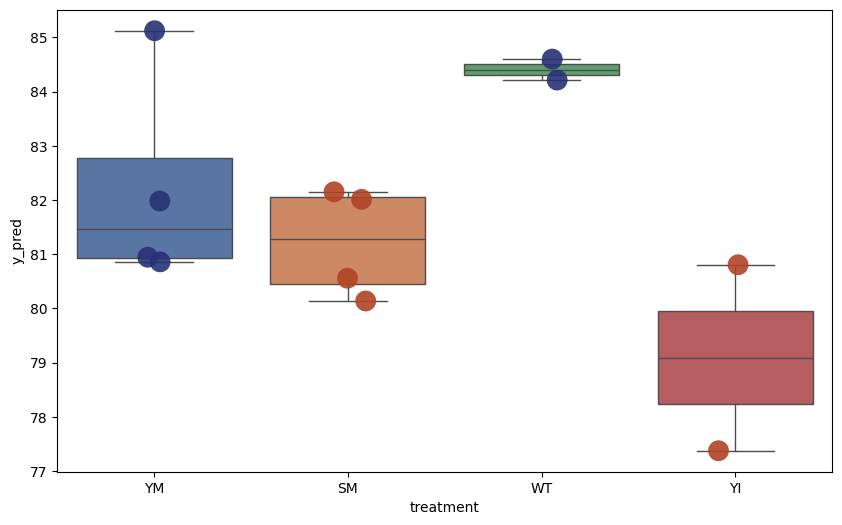

Components: 2
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   73.806581        YM  16wk
D13.YM.16wk.1  106.210602        YM  16wk
C19.SM.16wk.1   97.333084        SM  16wk
C12.SM.16wk.6   72.846140        SM  16wk
C11.SM.16wk.5   96.074871        SM  16wk
C10.SM.16wk.2   97.791189        SM  16wk
D16.YM.16wk.8  107.233760        YM  16wk
D14.YM.16wk.4  106.217518        YM  16wk
B8.WT.16wk.7   102.208876        WT  16wk
B6.WT.16wk.2   107.259800        WT  16wk
A18.YI.6wk.4    38.693863        YI   6wk
A17.YI.6wk.2    13.209912        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


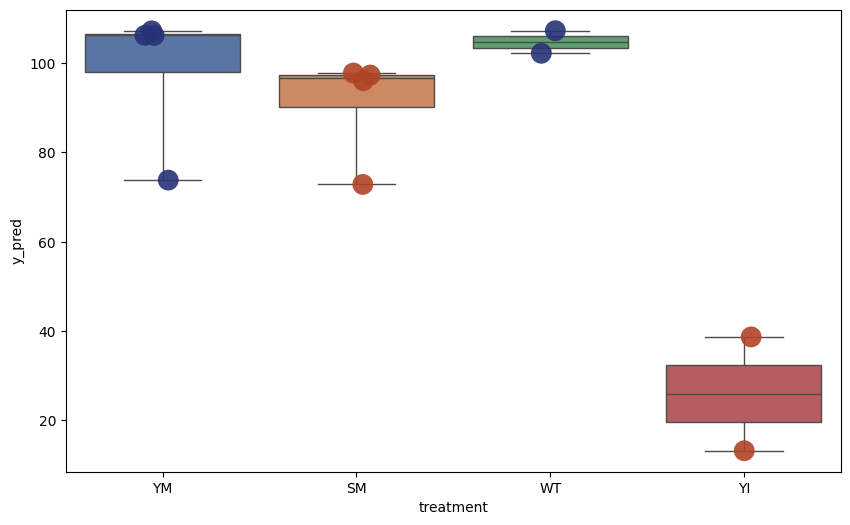

Components: 3
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   84.369170        YM  16wk
D13.YM.16wk.1  104.645197        YM  16wk
C19.SM.16wk.1   94.237161        SM  16wk
C12.SM.16wk.6   74.740695        SM  16wk
C11.SM.16wk.5   92.546659        SM  16wk
C10.SM.16wk.2   94.898365        SM  16wk
D16.YM.16wk.8   99.226684        YM  16wk
D14.YM.16wk.4  104.273438        YM  16wk
B8.WT.16wk.7    92.011875        WT  16wk
B6.WT.16wk.2    99.706813        WT  16wk
A18.YI.6wk.4    43.432040        YI   6wk
A17.YI.6wk.2    26.701633        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


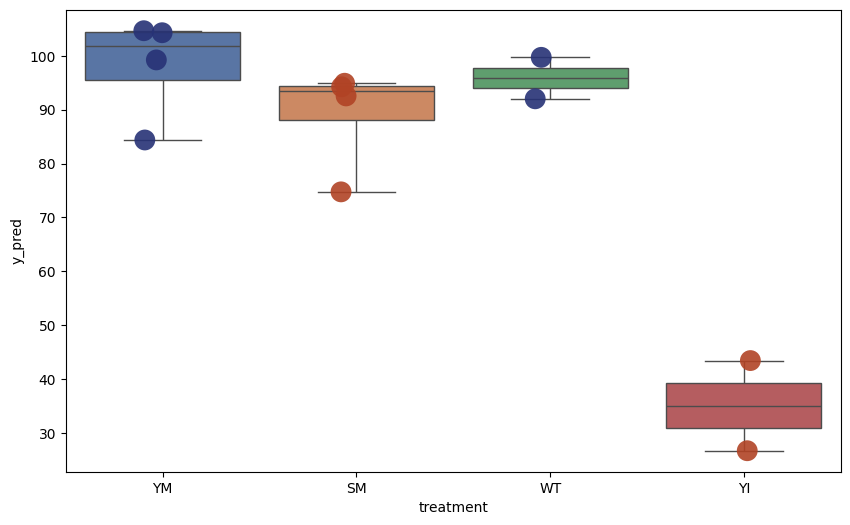

Components: 4
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   82.729698        YM  16wk
D13.YM.16wk.1  108.581071        YM  16wk
C19.SM.16wk.1   98.722126        SM  16wk
C12.SM.16wk.6   73.098550        SM  16wk
C11.SM.16wk.5   94.419926        SM  16wk
C10.SM.16wk.2   99.353879        SM  16wk
D16.YM.16wk.8   99.724804        YM  16wk
D14.YM.16wk.4  108.633044        YM  16wk
B8.WT.16wk.7    91.677357        WT  16wk
B6.WT.16wk.2   102.082045        WT  16wk
A18.YI.6wk.4    40.331572        YI   6wk
A17.YI.6wk.2    19.552732        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


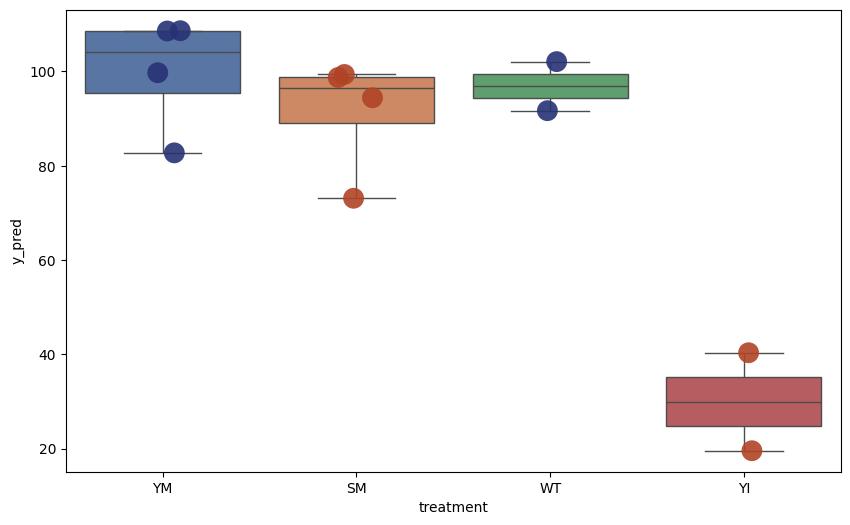

Components: 5
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   51.094810        YM  16wk
D13.YM.16wk.1   99.037875        YM  16wk
C19.SM.16wk.1   88.266567        SM  16wk
C12.SM.16wk.6   68.972483        SM  16wk
C11.SM.16wk.5   83.879571        SM  16wk
C10.SM.16wk.2   88.601895        SM  16wk
D16.YM.16wk.8   96.032572        YM  16wk
D14.YM.16wk.4  101.667603        YM  16wk
B8.WT.16wk.7    87.081456        WT  16wk
B6.WT.16wk.2    98.659254        WT  16wk
A18.YI.6wk.4    35.538460        YI   6wk
A17.YI.6wk.2    28.354319        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


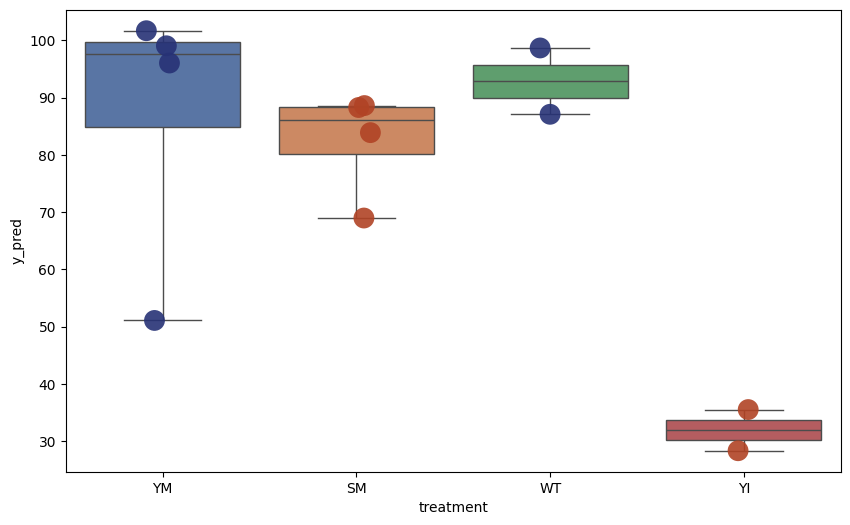

Components: 6
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                  y_pred treatment   age
D15.YM.16wk.3  87.253638        YM  16wk
D13.YM.16wk.1  81.903225        YM  16wk
C19.SM.16wk.1  80.684991        SM  16wk
C12.SM.16wk.6  69.896640        SM  16wk
C11.SM.16wk.5  73.837422        SM  16wk
C10.SM.16wk.2  81.079946        SM  16wk
D16.YM.16wk.8  78.241072        YM  16wk
D14.YM.16wk.4  90.956952        YM  16wk
B8.WT.16wk.7   79.219185        WT  16wk
B6.WT.16wk.2   88.731605        WT  16wk
A18.YI.6wk.4   45.195394        YI   6wk
A17.YI.6wk.2   38.941350        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


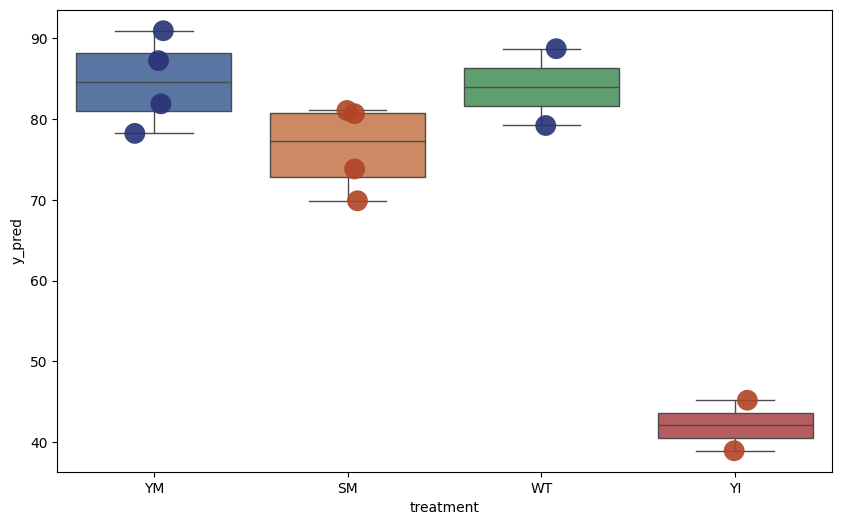

Components: 7
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                  y_pred treatment   age
D15.YM.16wk.3  82.023706        YM  16wk
D13.YM.16wk.1  92.602859        YM  16wk
C19.SM.16wk.1  87.807768        SM  16wk
C12.SM.16wk.6  75.317642        SM  16wk
C11.SM.16wk.5  81.846727        SM  16wk
C10.SM.16wk.2  88.389035        SM  16wk
D16.YM.16wk.8  86.543818        YM  16wk
D14.YM.16wk.4  99.625587        YM  16wk
B8.WT.16wk.7   87.641407        WT  16wk
B6.WT.16wk.2   96.714080        WT  16wk
A18.YI.6wk.4   49.680216        YI   6wk
A17.YI.6wk.2   37.698651        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


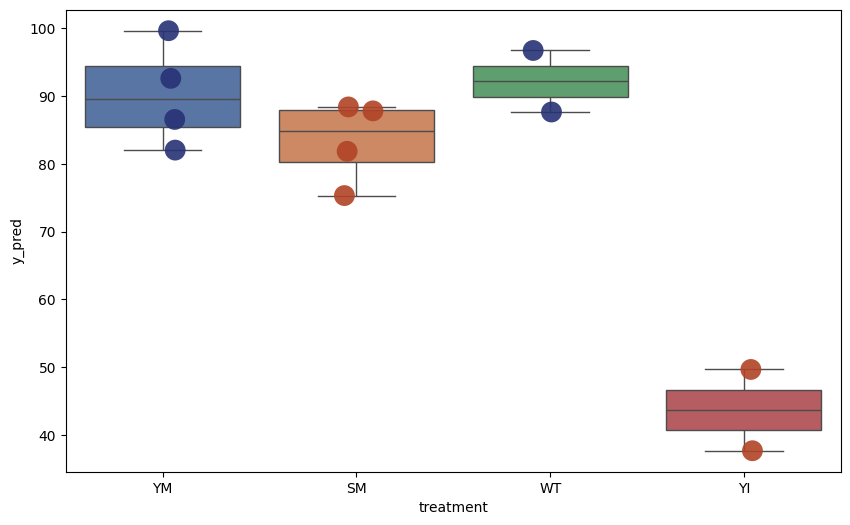

Components: 8
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                  y_pred treatment   age
D15.YM.16wk.3  84.241181        YM  16wk
D13.YM.16wk.1  86.174865        YM  16wk
C19.SM.16wk.1  83.638903        SM  16wk
C12.SM.16wk.6  72.499226        SM  16wk
C11.SM.16wk.5  72.121462        SM  16wk
C10.SM.16wk.2  83.841722        SM  16wk
D16.YM.16wk.8  75.387441        YM  16wk
D14.YM.16wk.4  91.240715        YM  16wk
B8.WT.16wk.7   72.465364        WT  16wk
B6.WT.16wk.2   86.405777        WT  16wk
A18.YI.6wk.4   45.618471        YI   6wk
A17.YI.6wk.2   40.664027        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


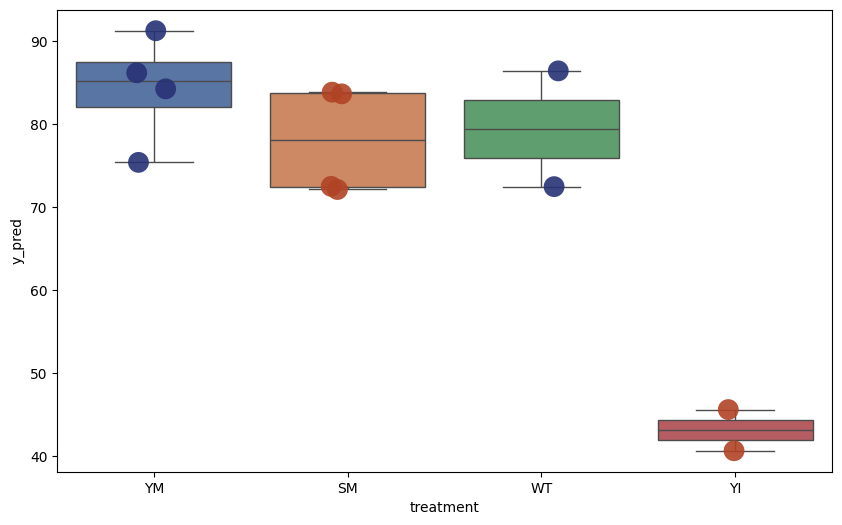

Components: 9
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   74.069481        YM  16wk
D13.YM.16wk.1   81.253844        YM  16wk
C19.SM.16wk.1   83.232072        SM  16wk
C12.SM.16wk.6   78.068990        SM  16wk
C11.SM.16wk.5   80.485094        SM  16wk
C10.SM.16wk.2   82.967131        SM  16wk
D16.YM.16wk.8   94.695746        YM  16wk
D14.YM.16wk.4  103.729386        YM  16wk
B8.WT.16wk.7    85.703466        WT  16wk
B6.WT.16wk.2   104.987747        WT  16wk
A18.YI.6wk.4    21.771977        YI   6wk
A17.YI.6wk.2    44.030388        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


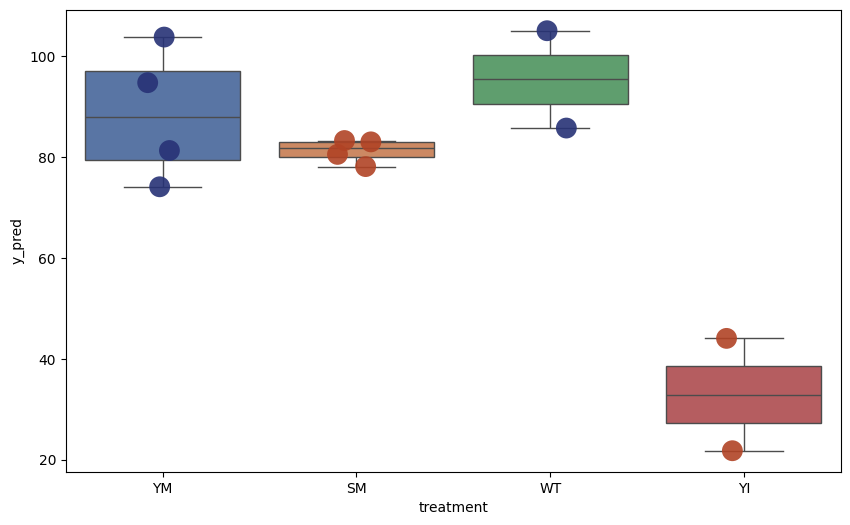

Components: 10
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   63.031133        YM  16wk
D13.YM.16wk.1   90.682889        YM  16wk
C19.SM.16wk.1   89.922895        SM  16wk
C12.SM.16wk.6   80.013437        SM  16wk
C11.SM.16wk.5   85.358391        SM  16wk
C10.SM.16wk.2   89.302067        SM  16wk
D16.YM.16wk.8  101.427861        YM  16wk
D14.YM.16wk.4  109.297477        YM  16wk
B8.WT.16wk.7    93.477905        WT  16wk
B6.WT.16wk.2   110.937808        WT  16wk
A18.YI.6wk.4    33.840870        YI   6wk
A17.YI.6wk.2    41.744530        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


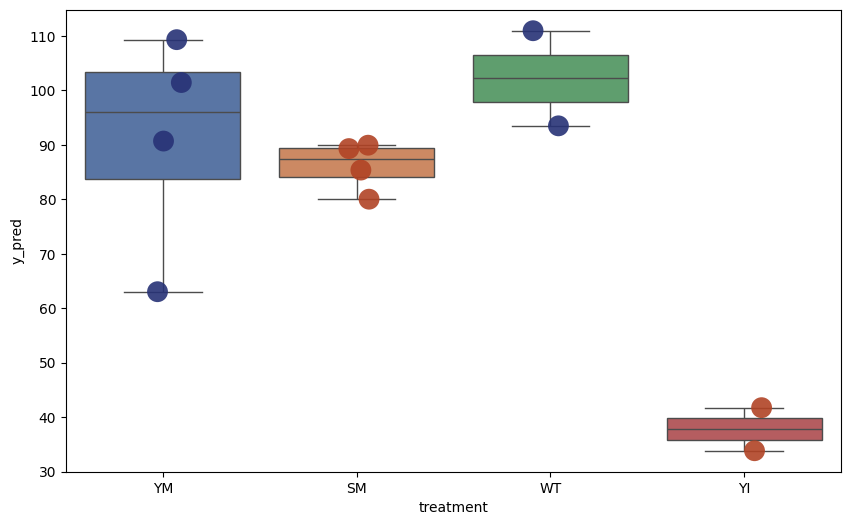

Components: 11
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   65.955503        YM  16wk
D13.YM.16wk.1   94.235718        YM  16wk
C19.SM.16wk.1   88.582930        SM  16wk
C12.SM.16wk.6   80.791869        SM  16wk
C11.SM.16wk.5   85.052400        SM  16wk
C10.SM.16wk.2   88.025126        SM  16wk
D16.YM.16wk.8  105.497030        YM  16wk
D14.YM.16wk.4  108.807553        YM  16wk
B8.WT.16wk.7    96.776498        WT  16wk
B6.WT.16wk.2   113.581492        WT  16wk
A18.YI.6wk.4    29.635847        YI   6wk
A17.YI.6wk.2    41.784363        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


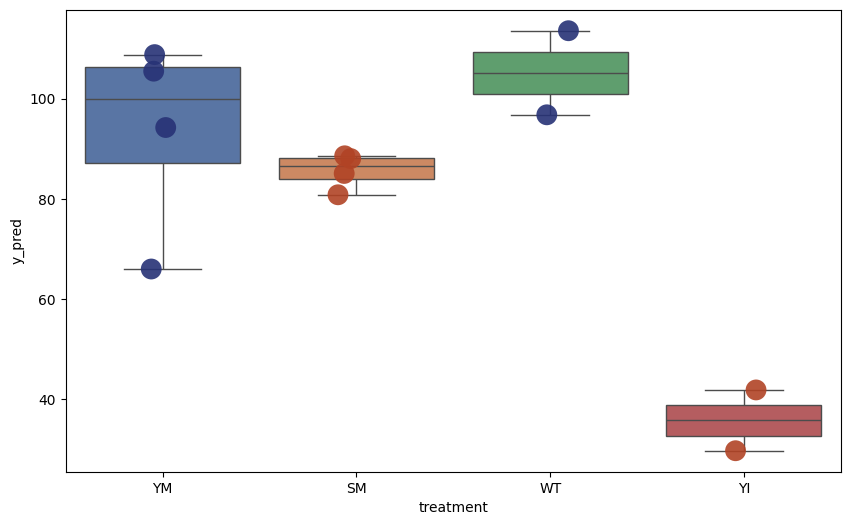

Components: 12
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3  -11.564105        YM  16wk
D13.YM.16wk.1  101.004350        YM  16wk
C19.SM.16wk.1   82.342978        SM  16wk
C12.SM.16wk.6   86.712003        SM  16wk
C11.SM.16wk.5   96.070820        SM  16wk
C10.SM.16wk.2   81.270035        SM  16wk
D16.YM.16wk.8  111.382125        YM  16wk
D14.YM.16wk.4  112.987080        YM  16wk
B8.WT.16wk.7   100.657678        WT  16wk
B6.WT.16wk.2   111.823848        WT  16wk
A18.YI.6wk.4     8.446572        YI   6wk
A17.YI.6wk.2    40.146590        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


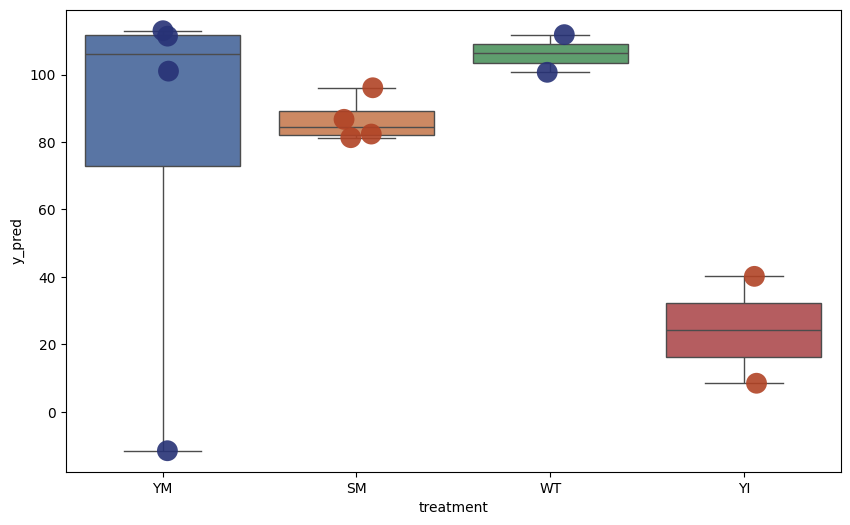

Components: 13
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3    6.388733        YM  16wk
D13.YM.16wk.1  100.600689        YM  16wk
C19.SM.16wk.1   83.067817        SM  16wk
C12.SM.16wk.6   85.027712        SM  16wk
C11.SM.16wk.5   94.522831        SM  16wk
C10.SM.16wk.2   81.809806        SM  16wk
D16.YM.16wk.8  110.777372        YM  16wk
D14.YM.16wk.4  109.873550        YM  16wk
B8.WT.16wk.7    99.702554        WT  16wk
B6.WT.16wk.2   113.073615        WT  16wk
A18.YI.6wk.4     7.207651        YI   6wk
A17.YI.6wk.2    39.655935        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


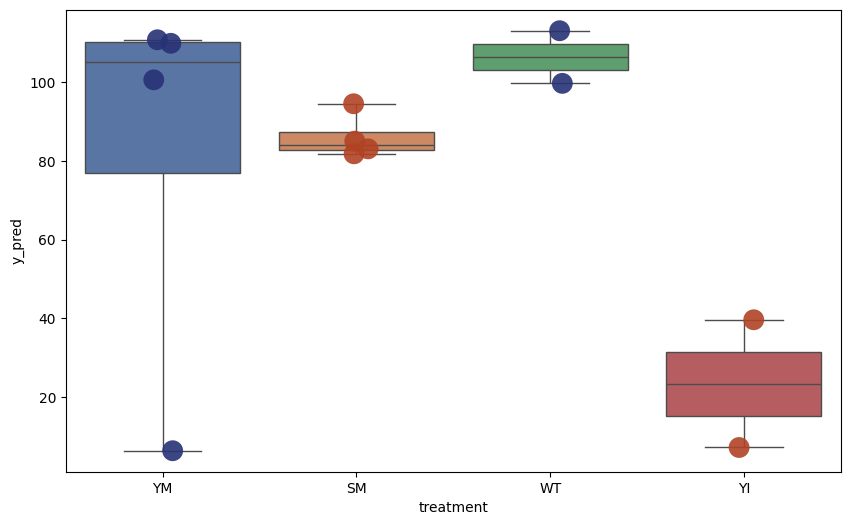

Components: 14
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3    3.542317        YM  16wk
D13.YM.16wk.1  100.835117        YM  16wk
C19.SM.16wk.1   81.965034        SM  16wk
C12.SM.16wk.6   85.163623        SM  16wk
C11.SM.16wk.5   94.167434        SM  16wk
C10.SM.16wk.2   80.893022        SM  16wk
D16.YM.16wk.8  111.630380        YM  16wk
D14.YM.16wk.4  108.088577        YM  16wk
B8.WT.16wk.7    98.421574        WT  16wk
B6.WT.16wk.2   113.083381        WT  16wk
A18.YI.6wk.4     7.531797        YI   6wk
A17.YI.6wk.2    39.455363        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


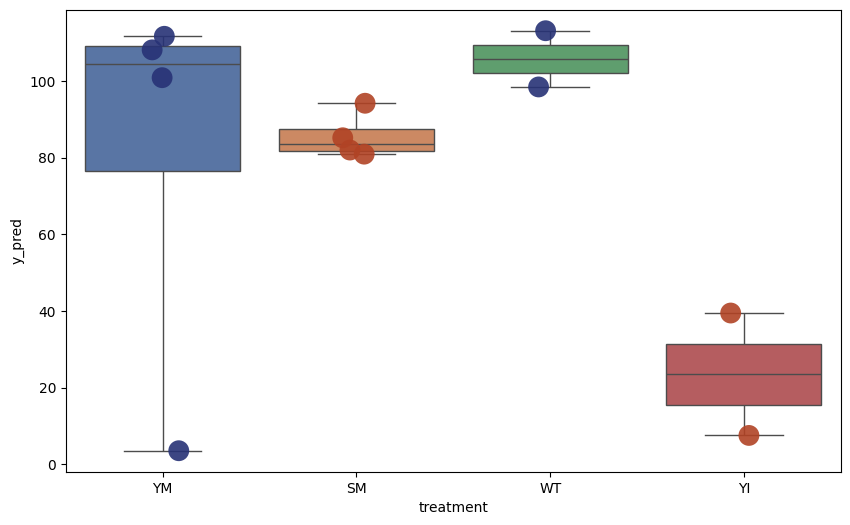

Components: 15
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   12.848508        YM  16wk
D13.YM.16wk.1   98.176714        YM  16wk
C19.SM.16wk.1   82.733498        SM  16wk
C12.SM.16wk.6   84.883013        SM  16wk
C11.SM.16wk.5   93.707732        SM  16wk
C10.SM.16wk.2   81.363804        SM  16wk
D16.YM.16wk.8  114.152090        YM  16wk
D14.YM.16wk.4  109.107294        YM  16wk
B8.WT.16wk.7   101.350903        WT  16wk
B6.WT.16wk.2   115.232150        WT  16wk
A18.YI.6wk.4     5.863726        YI   6wk
A17.YI.6wk.2    39.805829        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


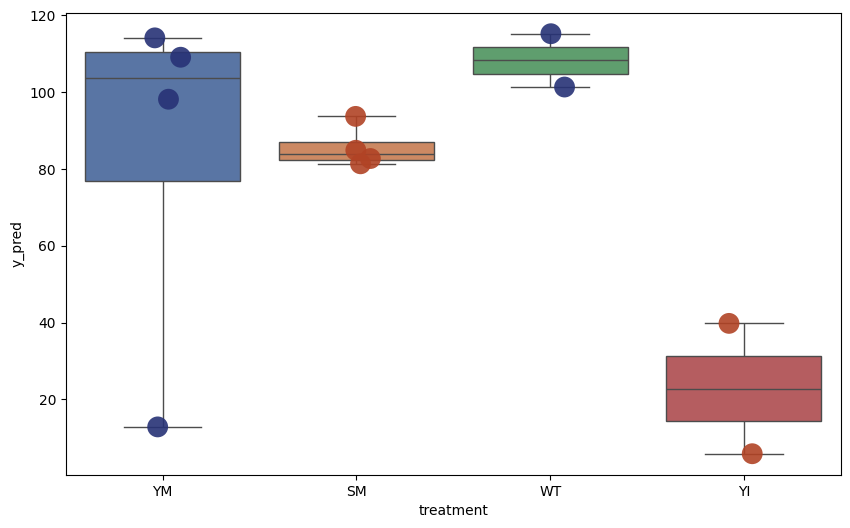

Components: 16
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   16.840501        YM  16wk
D13.YM.16wk.1   99.136664        YM  16wk
C19.SM.16wk.1   83.039547        SM  16wk
C12.SM.16wk.6   85.186897        SM  16wk
C11.SM.16wk.5   95.613193        SM  16wk
C10.SM.16wk.2   81.991232        SM  16wk
D16.YM.16wk.8  115.048240        YM  16wk
D14.YM.16wk.4  107.593989        YM  16wk
B8.WT.16wk.7   100.999215        WT  16wk
B6.WT.16wk.2   115.965214        WT  16wk
A18.YI.6wk.4    11.239988        YI   6wk
A17.YI.6wk.2    39.822920        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


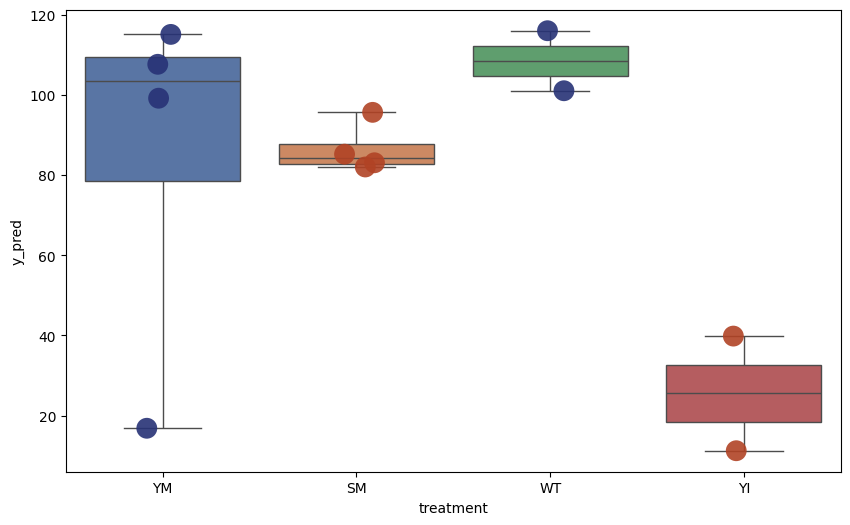

Components: 17
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   17.313066        YM  16wk
D13.YM.16wk.1   99.741691        YM  16wk
C19.SM.16wk.1   83.098903        SM  16wk
C12.SM.16wk.6   85.496895        SM  16wk
C11.SM.16wk.5   98.397999        SM  16wk
C10.SM.16wk.2   82.685549        SM  16wk
D16.YM.16wk.8  110.320720        YM  16wk
D14.YM.16wk.4  109.717228        YM  16wk
B8.WT.16wk.7    99.727425        WT  16wk
B6.WT.16wk.2   113.719307        WT  16wk
A18.YI.6wk.4    10.421641        YI   6wk
A17.YI.6wk.2    39.927143        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


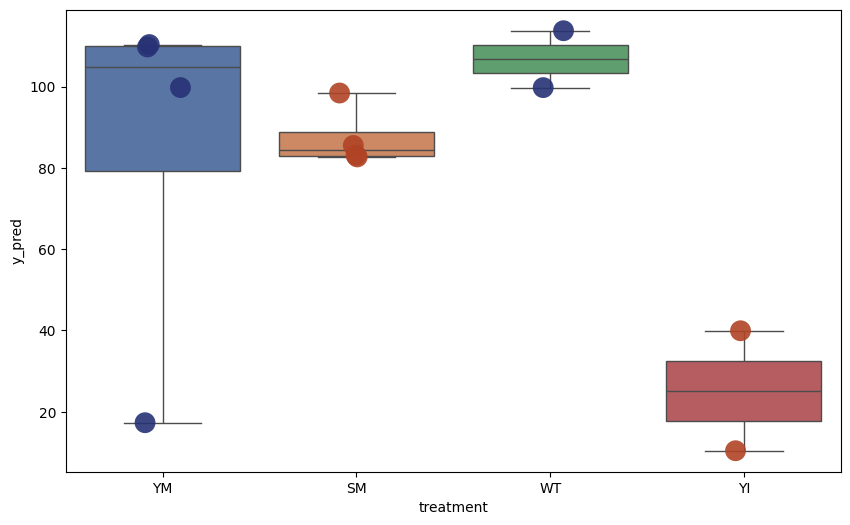

Components: 18
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3    3.450431        YM  16wk
D13.YM.16wk.1  100.222641        YM  16wk
C19.SM.16wk.1   82.971940        SM  16wk
C12.SM.16wk.6   85.951936        SM  16wk
C11.SM.16wk.5   98.716958        SM  16wk
C10.SM.16wk.2   82.726943        SM  16wk
D16.YM.16wk.8  110.150837        YM  16wk
D14.YM.16wk.4  110.131169        YM  16wk
B8.WT.16wk.7    99.882971        WT  16wk
B6.WT.16wk.2   113.158900        WT  16wk
A18.YI.6wk.4    12.298958        YI   6wk
A17.YI.6wk.2    40.091486        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


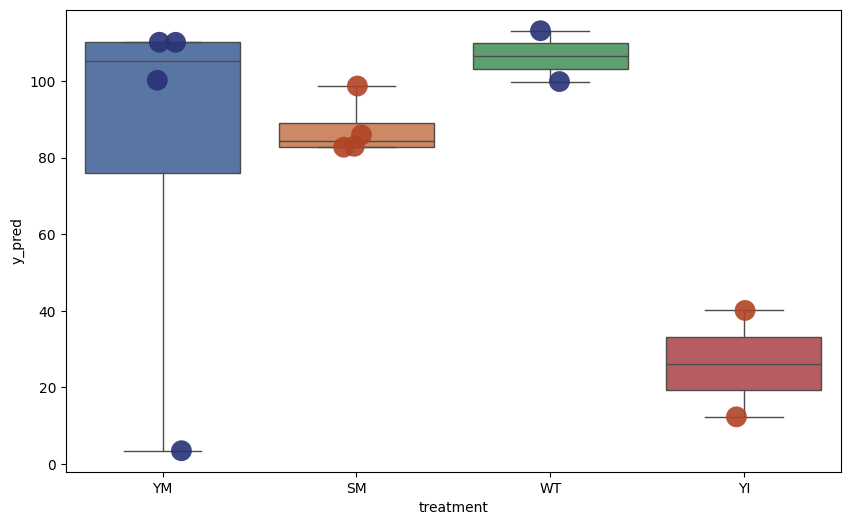

Components: 19
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3  -15.306325        YM  16wk
D13.YM.16wk.1  100.327756        YM  16wk
C19.SM.16wk.1   82.380332        SM  16wk
C12.SM.16wk.6   85.058134        SM  16wk
C11.SM.16wk.5   98.338136        SM  16wk
C10.SM.16wk.2   81.688632        SM  16wk
D16.YM.16wk.8  112.740564        YM  16wk
D14.YM.16wk.4  110.825453        YM  16wk
B8.WT.16wk.7   100.069300        WT  16wk
B6.WT.16wk.2   115.761255        WT  16wk
A18.YI.6wk.4    12.215940        YI   6wk
A17.YI.6wk.2    39.101961        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


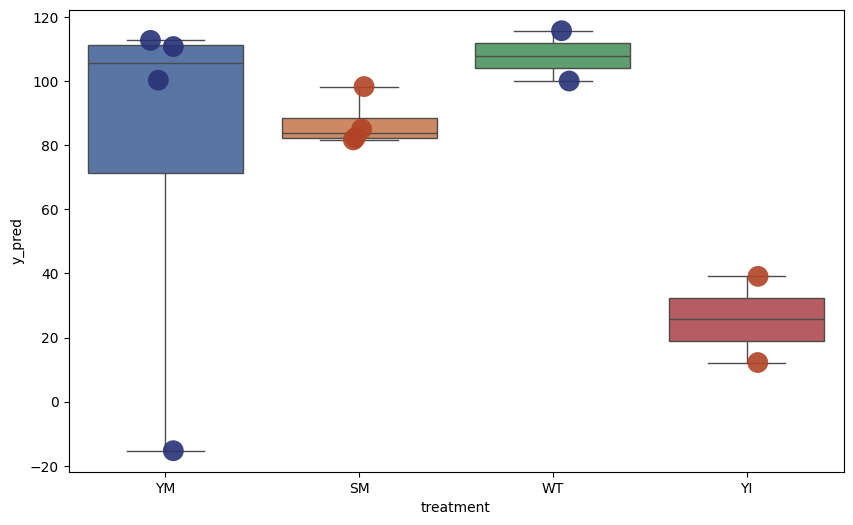

Components: 20
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3  -12.126910        YM  16wk
D13.YM.16wk.1   99.865435        YM  16wk
C19.SM.16wk.1   81.391930        SM  16wk
C12.SM.16wk.6   84.541539        SM  16wk
C11.SM.16wk.5   97.616247        SM  16wk
C10.SM.16wk.2   80.488365        SM  16wk
D16.YM.16wk.8  113.178870        YM  16wk
D14.YM.16wk.4  109.961356        YM  16wk
B8.WT.16wk.7    99.454491        WT  16wk
B6.WT.16wk.2   115.787938        WT  16wk
A18.YI.6wk.4    13.066606        YI   6wk
A17.YI.6wk.2    39.142089        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


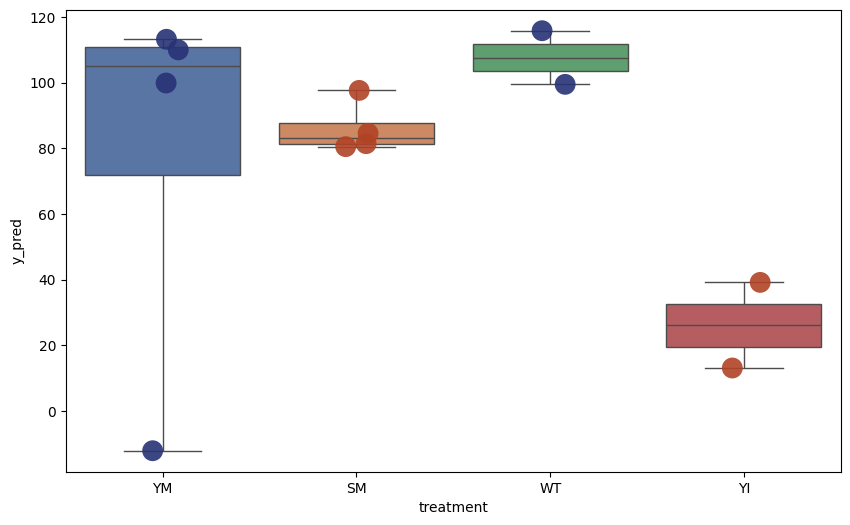

Components: 21
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3    5.553062        YM  16wk
D13.YM.16wk.1   99.991696        YM  16wk
C19.SM.16wk.1   83.655985        SM  16wk
C12.SM.16wk.6   85.382779        SM  16wk
C11.SM.16wk.5  101.113629        SM  16wk
C10.SM.16wk.2   82.509503        SM  16wk
D16.YM.16wk.8  111.258772        YM  16wk
D14.YM.16wk.4  115.267594        YM  16wk
B8.WT.16wk.7   101.461790        WT  16wk
B6.WT.16wk.2   117.076902        WT  16wk
A18.YI.6wk.4    14.618510        YI   6wk
A17.YI.6wk.2    38.907447        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


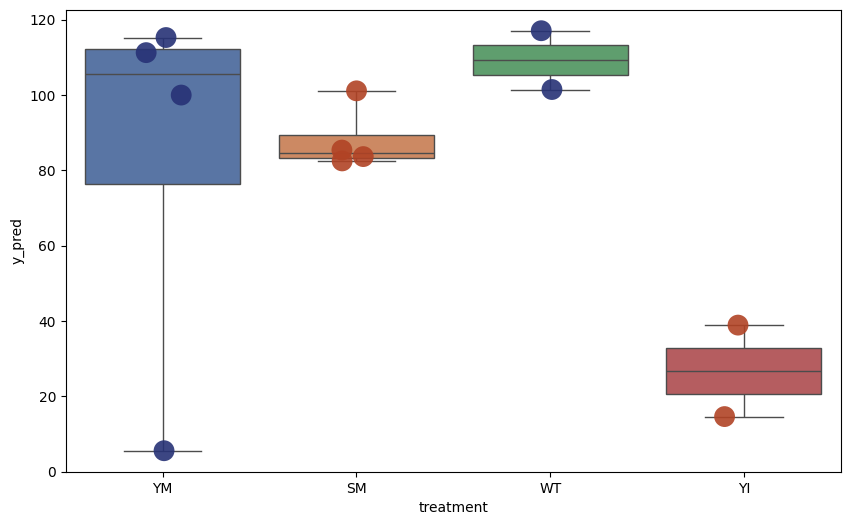

Components: 22
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3    0.115910        YM  16wk
D13.YM.16wk.1  100.259499        YM  16wk
C19.SM.16wk.1   82.192460        SM  16wk
C12.SM.16wk.6   84.965771        SM  16wk
C11.SM.16wk.5  100.086296        SM  16wk
C10.SM.16wk.2   81.231660        SM  16wk
D16.YM.16wk.8  111.665807        YM  16wk
D14.YM.16wk.4  113.971990        YM  16wk
B8.WT.16wk.7   100.962018        WT  16wk
B6.WT.16wk.2   116.206664        WT  16wk
A18.YI.6wk.4    14.819598        YI   6wk
A17.YI.6wk.2    38.987483        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


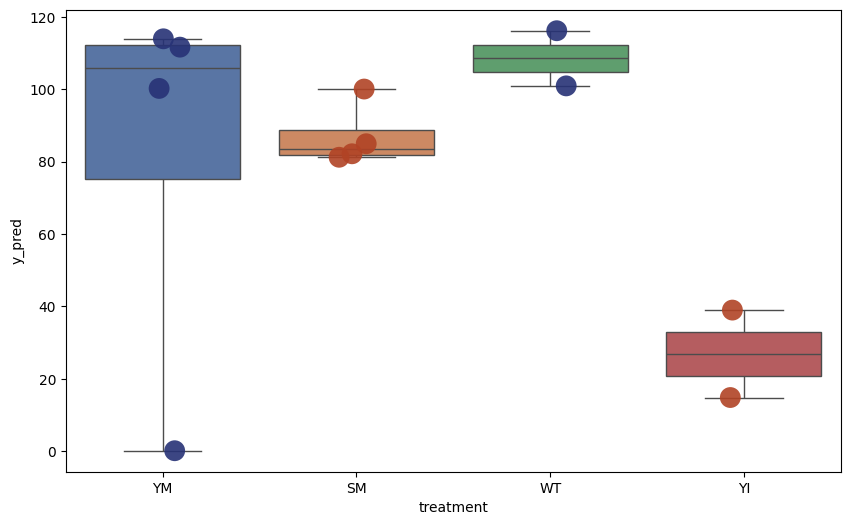

Components: 23
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3    5.771352        YM  16wk
D13.YM.16wk.1  100.170363        YM  16wk
C19.SM.16wk.1   82.938795        SM  16wk
C12.SM.16wk.6   84.764775        SM  16wk
C11.SM.16wk.5  100.734439        SM  16wk
C10.SM.16wk.2   82.143652        SM  16wk
D16.YM.16wk.8  110.595045        YM  16wk
D14.YM.16wk.4  113.637228        YM  16wk
B8.WT.16wk.7   100.753648        WT  16wk
B6.WT.16wk.2   116.839618        WT  16wk
A18.YI.6wk.4    16.579813        YI   6wk
A17.YI.6wk.2    39.128816        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


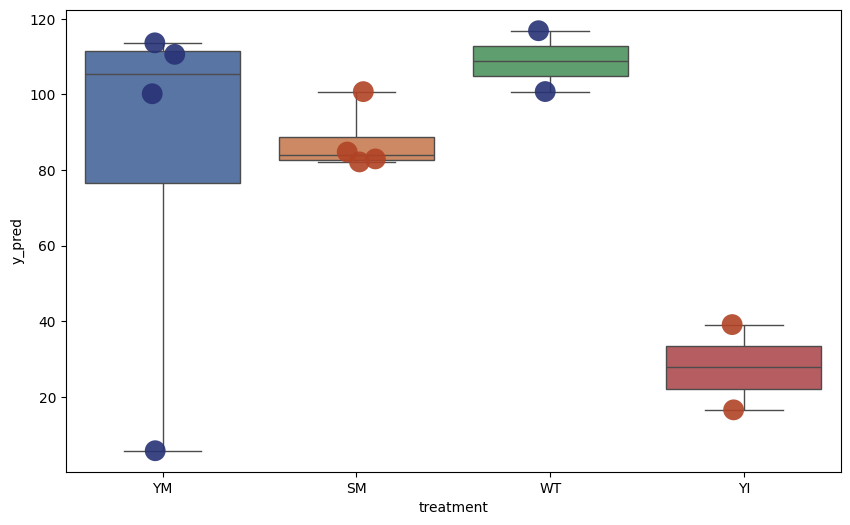

Components: 24
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3    3.431651        YM  16wk
D13.YM.16wk.1  102.011024        YM  16wk
C19.SM.16wk.1   83.514005        SM  16wk
C12.SM.16wk.6   85.778764        SM  16wk
C11.SM.16wk.5  101.008770        SM  16wk
C10.SM.16wk.2   82.620957        SM  16wk
D16.YM.16wk.8  112.404814        YM  16wk
D14.YM.16wk.4  114.381802        YM  16wk
B8.WT.16wk.7   101.941086        WT  16wk
B6.WT.16wk.2   117.143423        WT  16wk
A18.YI.6wk.4    10.171680        YI   6wk
A17.YI.6wk.2    39.214398        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


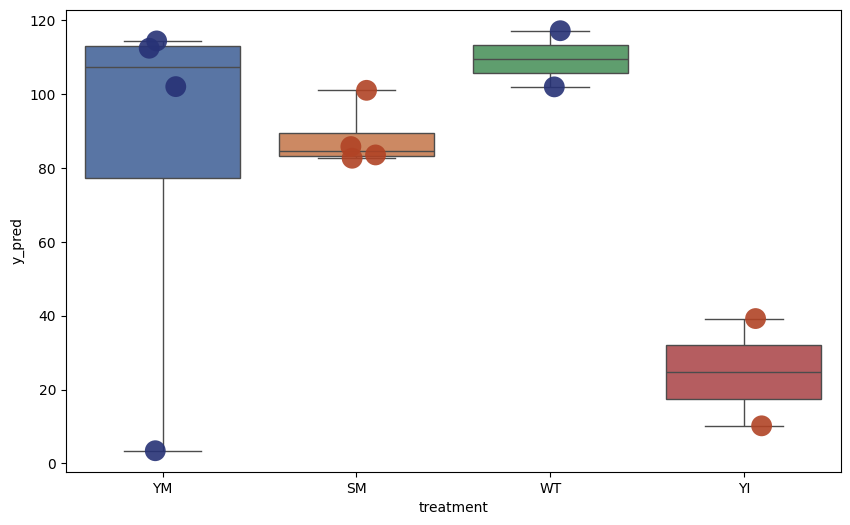

Components: 25
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3    3.854095        YM  16wk
D13.YM.16wk.1  102.785530        YM  16wk
C19.SM.16wk.1   85.070013        SM  16wk
C12.SM.16wk.6   85.971016        SM  16wk
C11.SM.16wk.5  100.956101        SM  16wk
C10.SM.16wk.2   84.700883        SM  16wk
D16.YM.16wk.8  112.188815        YM  16wk
D14.YM.16wk.4  114.272677        YM  16wk
B8.WT.16wk.7   102.023266        WT  16wk
B6.WT.16wk.2   116.462232        WT  16wk
A18.YI.6wk.4    12.073508        YI   6wk
A17.YI.6wk.2    39.468519        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


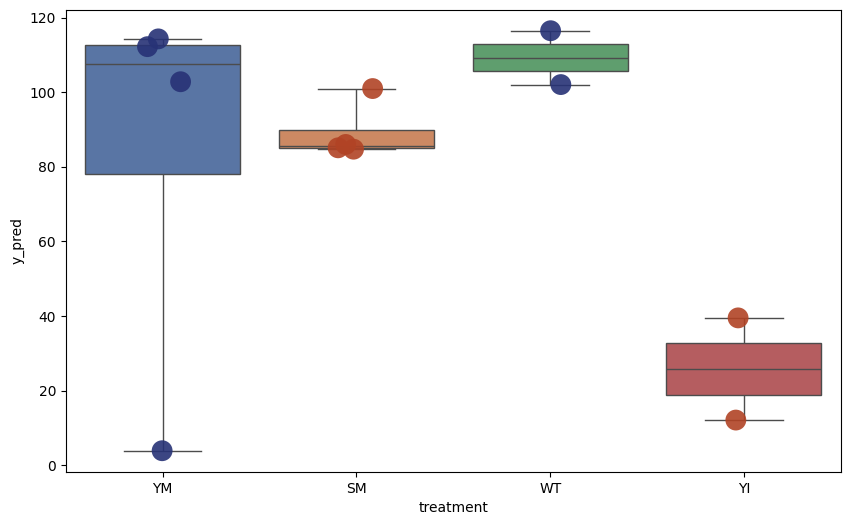

Components: 26
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   -7.475319        YM  16wk
D13.YM.16wk.1  101.217473        YM  16wk
C19.SM.16wk.1   82.745376        SM  16wk
C12.SM.16wk.6   85.647021        SM  16wk
C11.SM.16wk.5  101.126859        SM  16wk
C10.SM.16wk.2   81.725321        SM  16wk
D16.YM.16wk.8  112.096931        YM  16wk
D14.YM.16wk.4  114.783040        YM  16wk
B8.WT.16wk.7   100.918290        WT  16wk
B6.WT.16wk.2   116.669164        WT  16wk
A18.YI.6wk.4    15.634038        YI   6wk
A17.YI.6wk.2    38.425200        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


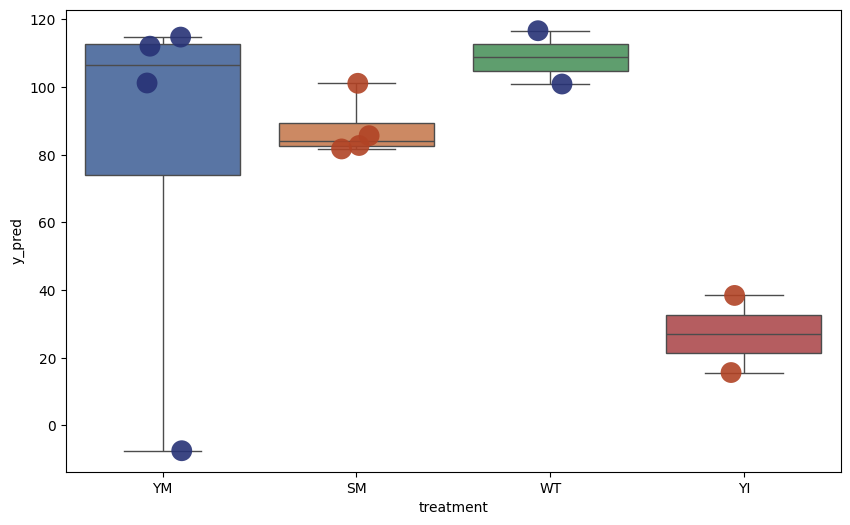

Components: 27
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   11.831908        YM  16wk
D13.YM.16wk.1   99.427771        YM  16wk
C19.SM.16wk.1   85.937809        SM  16wk
C12.SM.16wk.6   87.382632        SM  16wk
C11.SM.16wk.5  103.481137        SM  16wk
C10.SM.16wk.2   85.636610        SM  16wk
D16.YM.16wk.8  112.218756        YM  16wk
D14.YM.16wk.4  114.496693        YM  16wk
B8.WT.16wk.7   102.918568        WT  16wk
B6.WT.16wk.2   118.281923        WT  16wk
A18.YI.6wk.4    21.410773        YI   6wk
A17.YI.6wk.2    40.880934        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


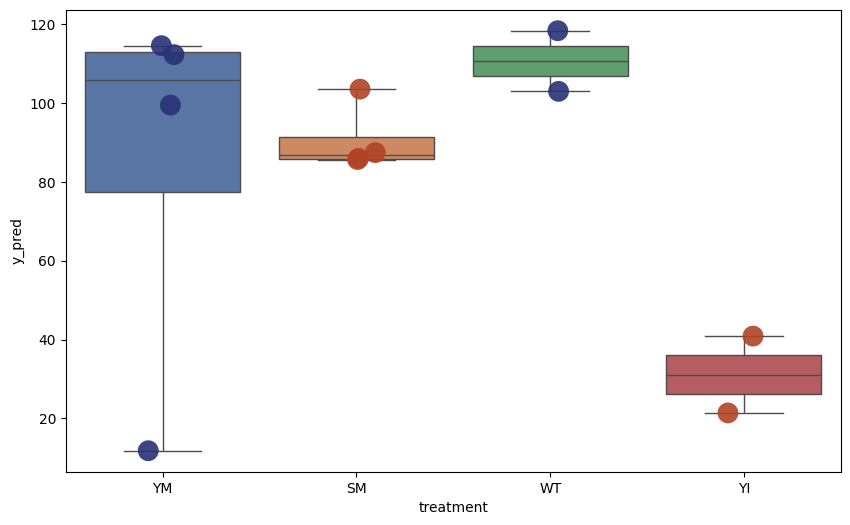

Components: 28
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   15.960924        YM  16wk
D13.YM.16wk.1  101.564217        YM  16wk
C19.SM.16wk.1   85.054716        SM  16wk
C12.SM.16wk.6   87.612574        SM  16wk
C11.SM.16wk.5  105.494481        SM  16wk
C10.SM.16wk.2   83.766479        SM  16wk
D16.YM.16wk.8  112.676349        YM  16wk
D14.YM.16wk.4  115.382114        YM  16wk
B8.WT.16wk.7   103.638065        WT  16wk
B6.WT.16wk.2   118.430948        WT  16wk
A18.YI.6wk.4    21.816186        YI   6wk
A17.YI.6wk.2    40.426538        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


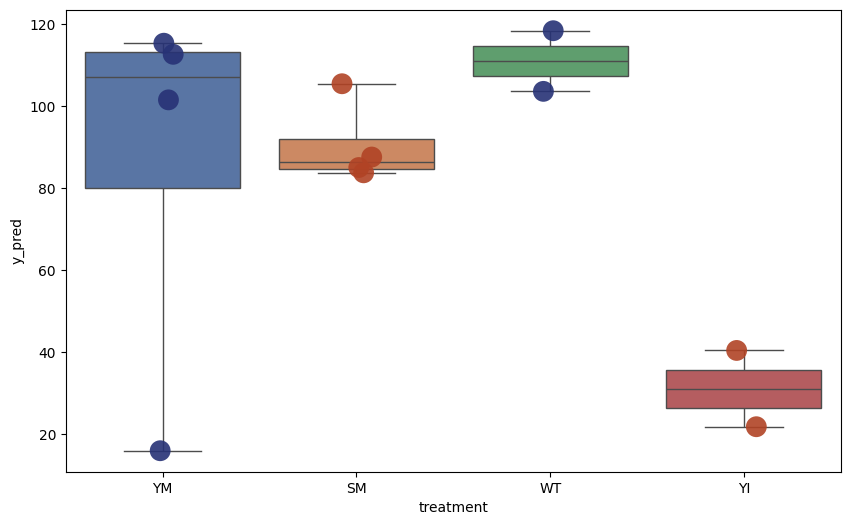

Components: 29
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   14.209693        YM  16wk
D13.YM.16wk.1   99.687776        YM  16wk
C19.SM.16wk.1   84.003101        SM  16wk
C12.SM.16wk.6   87.212549        SM  16wk
C11.SM.16wk.5  102.504136        SM  16wk
C10.SM.16wk.2   83.387897        SM  16wk
D16.YM.16wk.8  112.336558        YM  16wk
D14.YM.16wk.4  111.897835        YM  16wk
B8.WT.16wk.7   102.736728        WT  16wk
B6.WT.16wk.2   116.185829        WT  16wk
A18.YI.6wk.4    16.752312        YI   6wk
A17.YI.6wk.2    39.423344        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


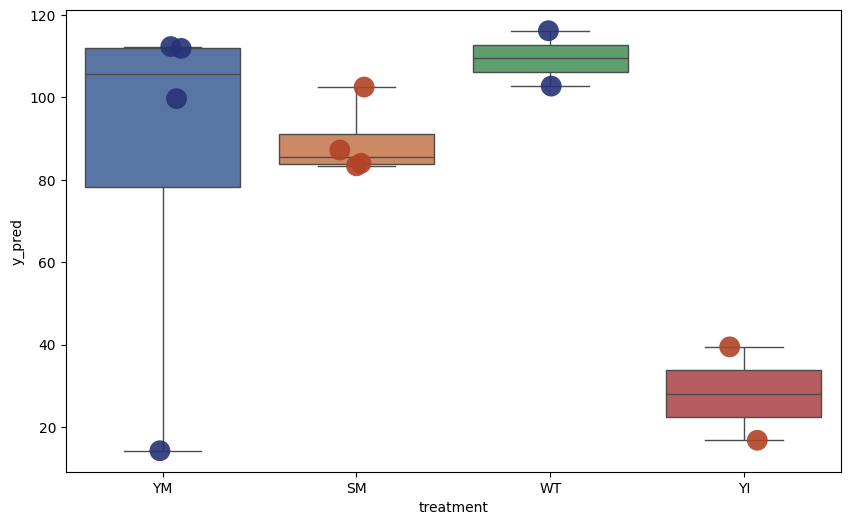

Components: 30
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   -3.020414        YM  16wk
D13.YM.16wk.1  105.003929        YM  16wk
C19.SM.16wk.1   83.551937        SM  16wk
C12.SM.16wk.6   86.534615        SM  16wk
C11.SM.16wk.5  102.733733        SM  16wk
C10.SM.16wk.2   82.890434        SM  16wk
D16.YM.16wk.8  111.886226        YM  16wk
D14.YM.16wk.4  115.717509        YM  16wk
B8.WT.16wk.7   102.719601        WT  16wk
B6.WT.16wk.2   117.453721        WT  16wk
A18.YI.6wk.4    14.758186        YI   6wk
A17.YI.6wk.2    39.939414        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


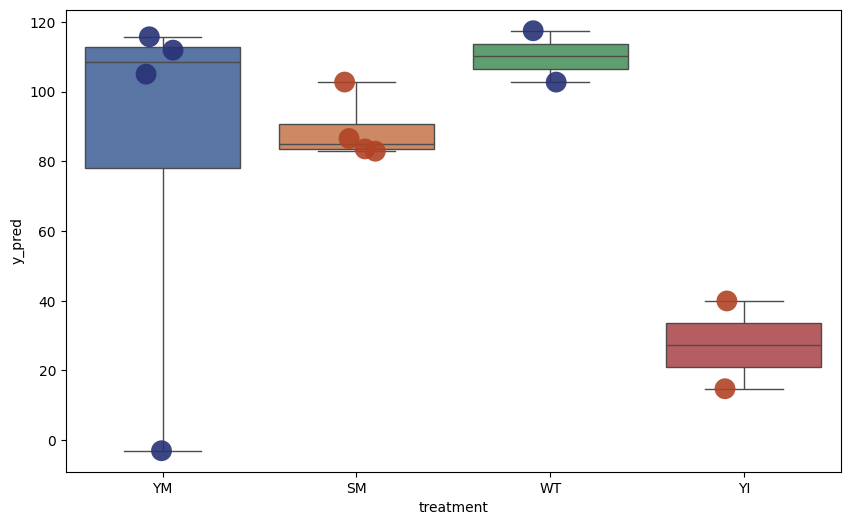

Components: 31
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   14.720579        YM  16wk
D13.YM.16wk.1  100.664297        YM  16wk
C19.SM.16wk.1   84.725733        SM  16wk
C12.SM.16wk.6   86.964322        SM  16wk
C11.SM.16wk.5  103.328298        SM  16wk
C10.SM.16wk.2   84.265631        SM  16wk
D16.YM.16wk.8  112.574011        YM  16wk
D14.YM.16wk.4  112.567935        YM  16wk
B8.WT.16wk.7   103.320816        WT  16wk
B6.WT.16wk.2   117.857873        WT  16wk
A18.YI.6wk.4    23.896154        YI   6wk
A17.YI.6wk.2    39.885687        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


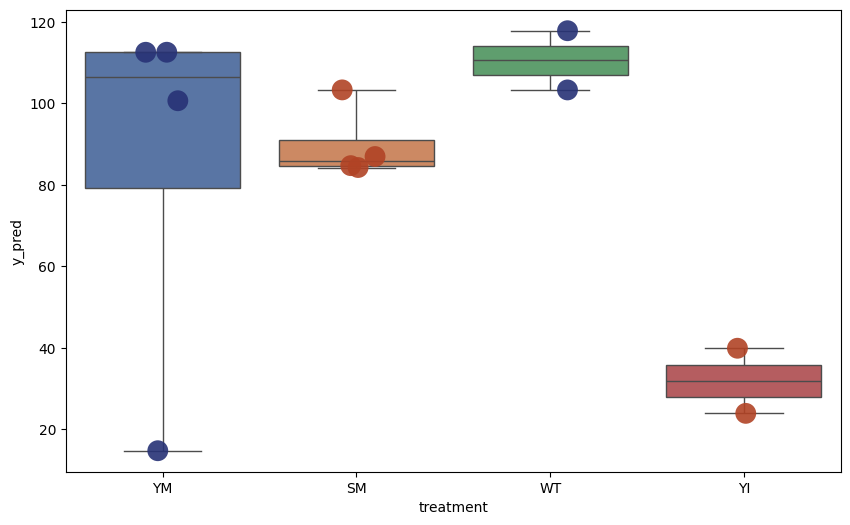

Components: 32
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   20.116597        YM  16wk
D13.YM.16wk.1  100.081101        YM  16wk
C19.SM.16wk.1   84.316784        SM  16wk
C12.SM.16wk.6   87.947270        SM  16wk
C11.SM.16wk.5  104.236267        SM  16wk
C10.SM.16wk.2   83.258819        SM  16wk
D16.YM.16wk.8  111.705684        YM  16wk
D14.YM.16wk.4  114.604893        YM  16wk
B8.WT.16wk.7   103.189152        WT  16wk
B6.WT.16wk.2   117.519272        WT  16wk
A18.YI.6wk.4    21.605716        YI   6wk
A17.YI.6wk.2    40.527840        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


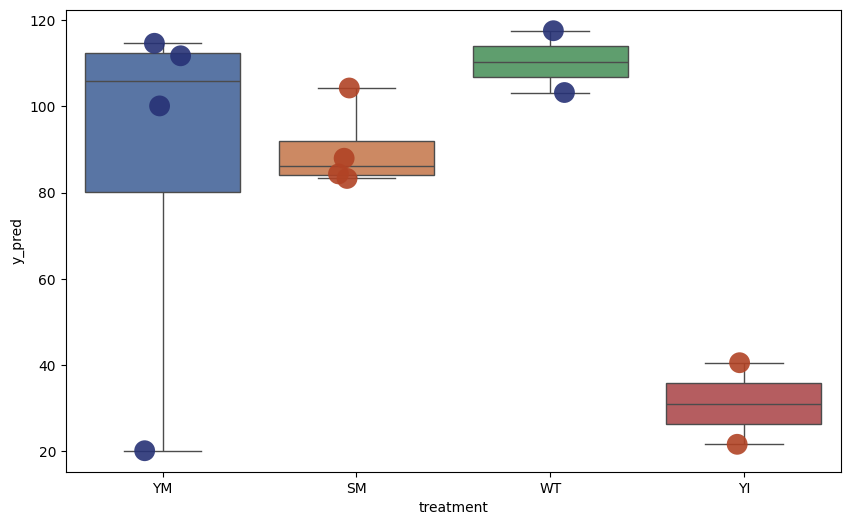

Components: 33
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   17.363249        YM  16wk
D13.YM.16wk.1   96.736435        YM  16wk
C19.SM.16wk.1   84.798494        SM  16wk
C12.SM.16wk.6   87.074952        SM  16wk
C11.SM.16wk.5  103.242974        SM  16wk
C10.SM.16wk.2   84.282580        SM  16wk
D16.YM.16wk.8  111.101977        YM  16wk
D14.YM.16wk.4  111.422026        YM  16wk
B8.WT.16wk.7   102.211226        WT  16wk
B6.WT.16wk.2   116.665843        WT  16wk
A18.YI.6wk.4    22.326485        YI   6wk
A17.YI.6wk.2    40.046405        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


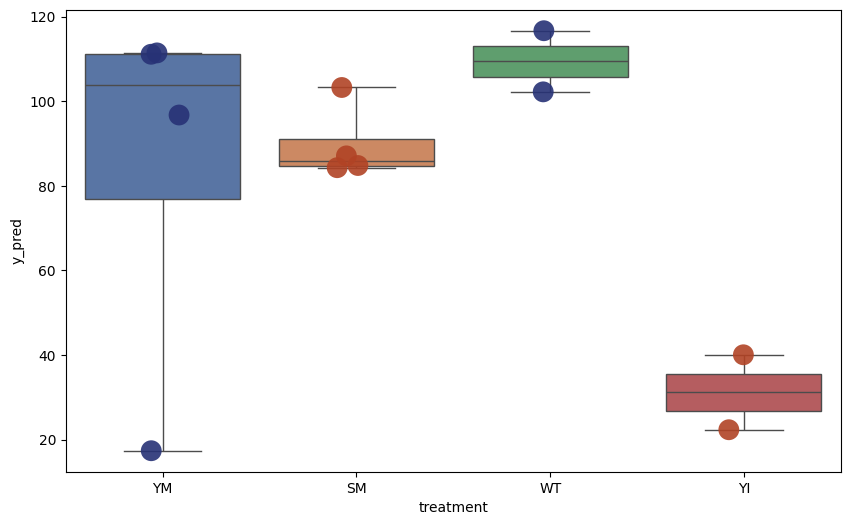

Components: 34
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   17.971179        YM  16wk
D13.YM.16wk.1  102.342812        YM  16wk
C19.SM.16wk.1   85.825393        SM  16wk
C12.SM.16wk.6   87.868673        SM  16wk
C11.SM.16wk.5  105.145823        SM  16wk
C10.SM.16wk.2   85.777114        SM  16wk
D16.YM.16wk.8  113.252954        YM  16wk
D14.YM.16wk.4  114.293600        YM  16wk
B8.WT.16wk.7   103.700205        WT  16wk
B6.WT.16wk.2   117.914902        WT  16wk
A18.YI.6wk.4    22.275108        YI   6wk
A17.YI.6wk.2    40.101700        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


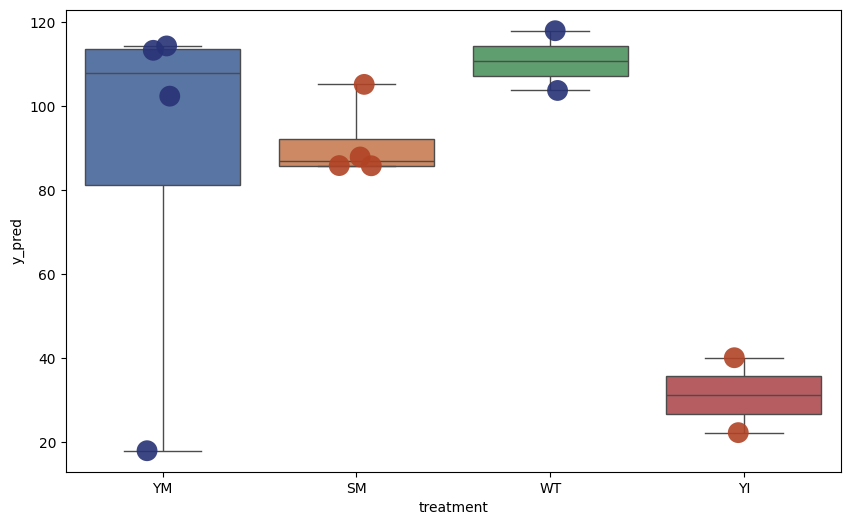

Components: 35
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   22.721133        YM  16wk
D13.YM.16wk.1   99.367161        YM  16wk
C19.SM.16wk.1   86.256421        SM  16wk
C12.SM.16wk.6   87.997188        SM  16wk
C11.SM.16wk.5  104.109717        SM  16wk
C10.SM.16wk.2   85.862486        SM  16wk
D16.YM.16wk.8  111.907950        YM  16wk
D14.YM.16wk.4  114.325952        YM  16wk
B8.WT.16wk.7   102.819747        WT  16wk
B6.WT.16wk.2   117.193920        WT  16wk
A18.YI.6wk.4    21.041237        YI   6wk
A17.YI.6wk.2    40.748191        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


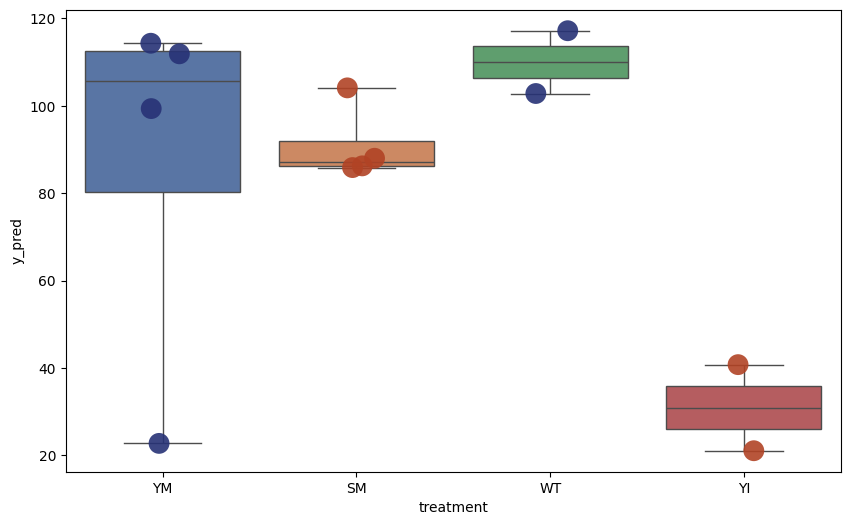

Components: 36
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   13.566985        YM  16wk
D13.YM.16wk.1  100.717135        YM  16wk
C19.SM.16wk.1   85.377246        SM  16wk
C12.SM.16wk.6   87.058723        SM  16wk
C11.SM.16wk.5  103.261571        SM  16wk
C10.SM.16wk.2   84.944011        SM  16wk
D16.YM.16wk.8  112.946244        YM  16wk
D14.YM.16wk.4  111.868590        YM  16wk
B8.WT.16wk.7   103.418443        WT  16wk
B6.WT.16wk.2   117.176333        WT  16wk
A18.YI.6wk.4    19.215354        YI   6wk
A17.YI.6wk.2    40.156970        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


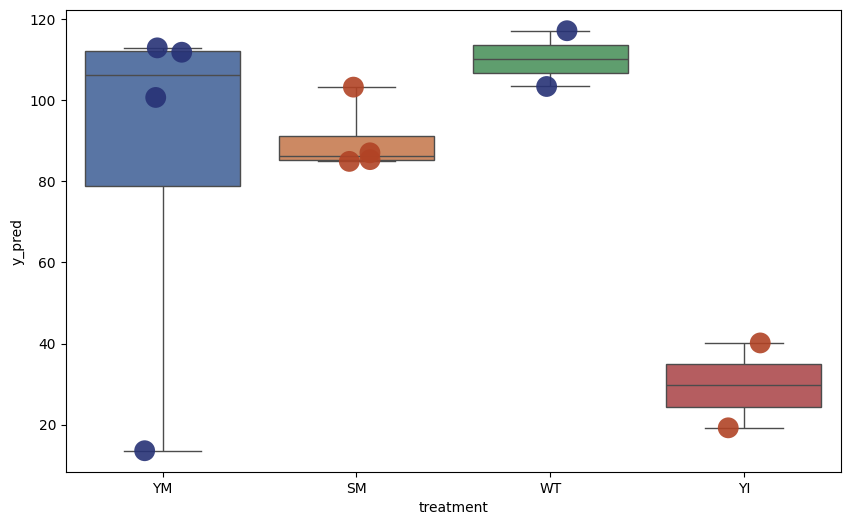

Components: 37
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   23.173193        YM  16wk
D13.YM.16wk.1  100.961141        YM  16wk
C19.SM.16wk.1   85.690645        SM  16wk
C12.SM.16wk.6   87.709565        SM  16wk
C11.SM.16wk.5  104.458640        SM  16wk
C10.SM.16wk.2   84.753144        SM  16wk
D16.YM.16wk.8  112.090153        YM  16wk
D14.YM.16wk.4  113.637929        YM  16wk
B8.WT.16wk.7   103.215372        WT  16wk
B6.WT.16wk.2   116.977095        WT  16wk
A18.YI.6wk.4    18.485689        YI   6wk
A17.YI.6wk.2    40.532521        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


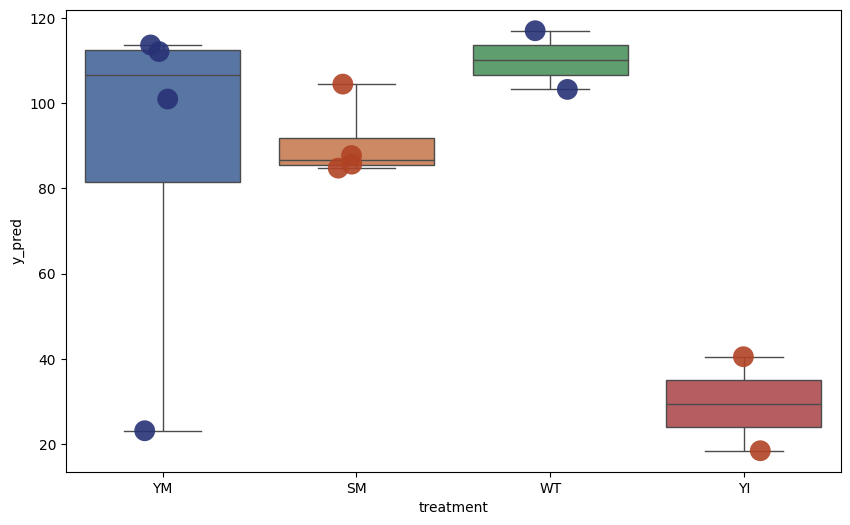

Components: 38
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   25.105567        YM  16wk
D13.YM.16wk.1  100.682184        YM  16wk
C19.SM.16wk.1   85.511808        SM  16wk
C12.SM.16wk.6   88.359474        SM  16wk
C11.SM.16wk.5  103.783363        SM  16wk
C10.SM.16wk.2   84.578624        SM  16wk
D16.YM.16wk.8  112.851353        YM  16wk
D14.YM.16wk.4  114.528319        YM  16wk
B8.WT.16wk.7   102.539157        WT  16wk
B6.WT.16wk.2   117.023661        WT  16wk
A18.YI.6wk.4    20.821361        YI   6wk
A17.YI.6wk.2    40.613695        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


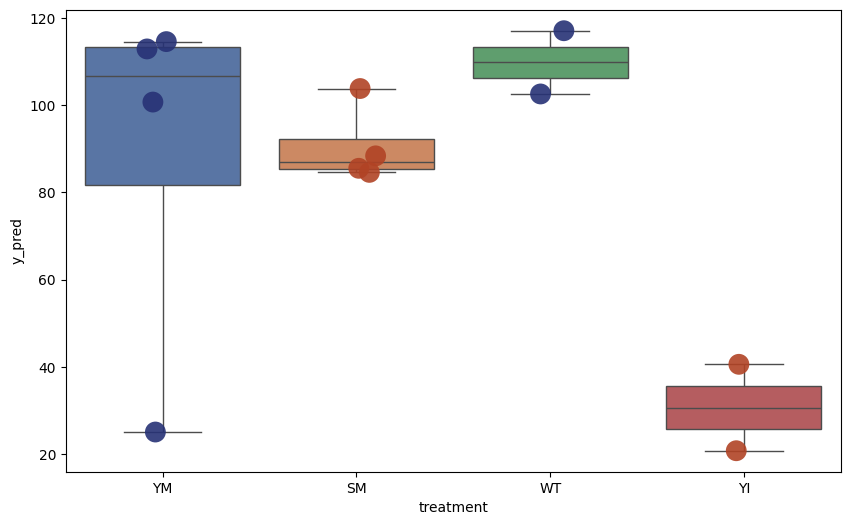

Components: 39
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   23.873980        YM  16wk
D13.YM.16wk.1  100.222210        YM  16wk
C19.SM.16wk.1   86.027881        SM  16wk
C12.SM.16wk.6   87.975279        SM  16wk
C11.SM.16wk.5  104.027770        SM  16wk
C10.SM.16wk.2   85.525355        SM  16wk
D16.YM.16wk.8  113.285948        YM  16wk
D14.YM.16wk.4  113.490941        YM  16wk
B8.WT.16wk.7   103.237183        WT  16wk
B6.WT.16wk.2   117.755885        WT  16wk
A18.YI.6wk.4    22.952128        YI   6wk
A17.YI.6wk.2    40.410035        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


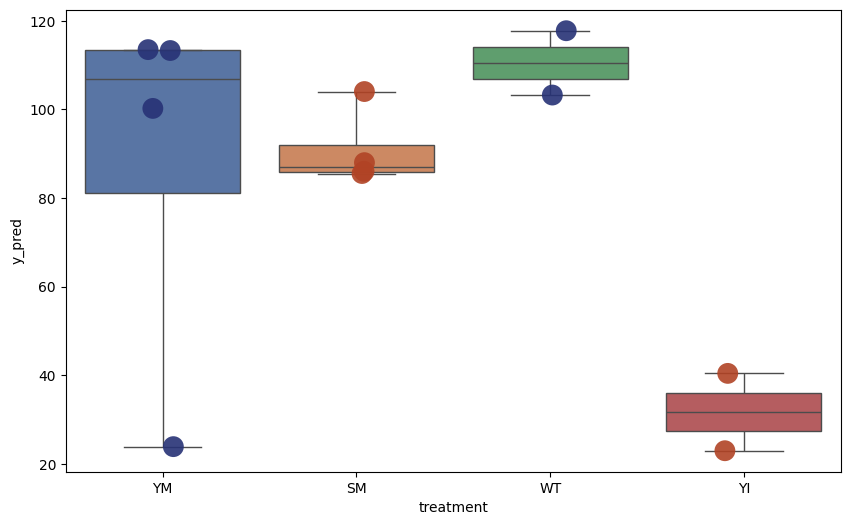

Components: 40
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   27.833193        YM  16wk
D13.YM.16wk.1  100.375090        YM  16wk
C19.SM.16wk.1   86.702012        SM  16wk
C12.SM.16wk.6   88.275932        SM  16wk
C11.SM.16wk.5  103.330809        SM  16wk
C10.SM.16wk.2   86.307021        SM  16wk
D16.YM.16wk.8  113.331553        YM  16wk
D14.YM.16wk.4  113.199186        YM  16wk
B8.WT.16wk.7   102.468311        WT  16wk
B6.WT.16wk.2   116.911432        WT  16wk
A18.YI.6wk.4    21.385525        YI   6wk
A17.YI.6wk.2    40.823203        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


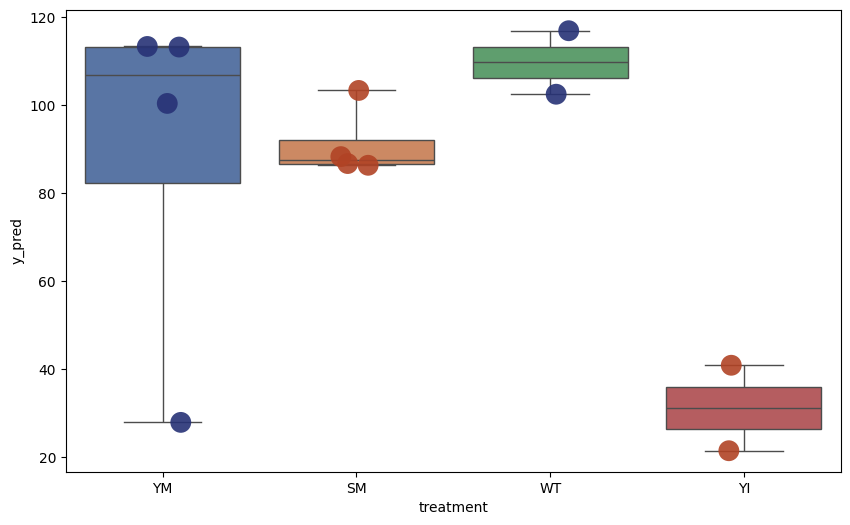

Components: 41
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   25.948555        YM  16wk
D13.YM.16wk.1  102.371742        YM  16wk
C19.SM.16wk.1   86.484676        SM  16wk
C12.SM.16wk.6   88.544097        SM  16wk
C11.SM.16wk.5  103.091730        SM  16wk
C10.SM.16wk.2   86.638500        SM  16wk
D16.YM.16wk.8  112.857868        YM  16wk
D14.YM.16wk.4  114.485068        YM  16wk
B8.WT.16wk.7   102.437155        WT  16wk
B6.WT.16wk.2   116.433056        WT  16wk
A18.YI.6wk.4    25.734779        YI   6wk
A17.YI.6wk.2    42.084897        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


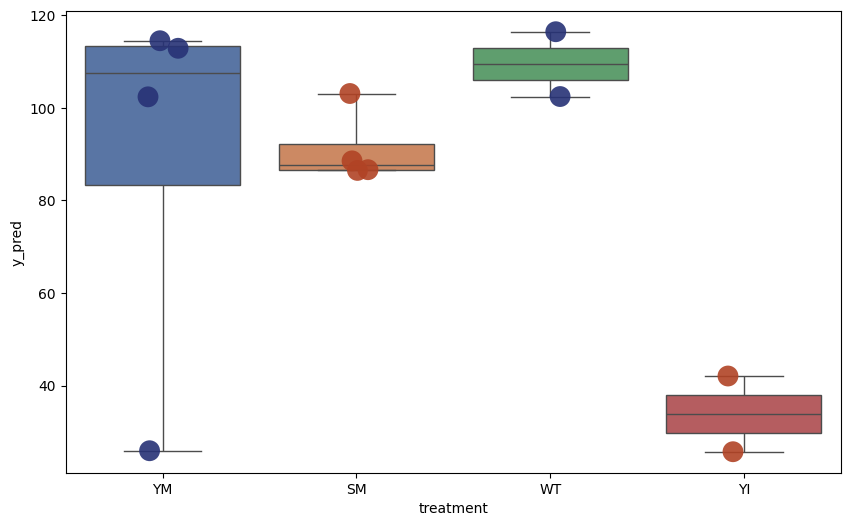

Components: 42
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   24.770834        YM  16wk
D13.YM.16wk.1   97.761824        YM  16wk
C19.SM.16wk.1   87.487205        SM  16wk
C12.SM.16wk.6   87.626371        SM  16wk
C11.SM.16wk.5  101.956386        SM  16wk
C10.SM.16wk.2   88.147274        SM  16wk
D16.YM.16wk.8  112.444570        YM  16wk
D14.YM.16wk.4  112.232812        YM  16wk
B8.WT.16wk.7   102.092195        WT  16wk
B6.WT.16wk.2   116.948758        WT  16wk
A18.YI.6wk.4    23.615943        YI   6wk
A17.YI.6wk.2    41.890621        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


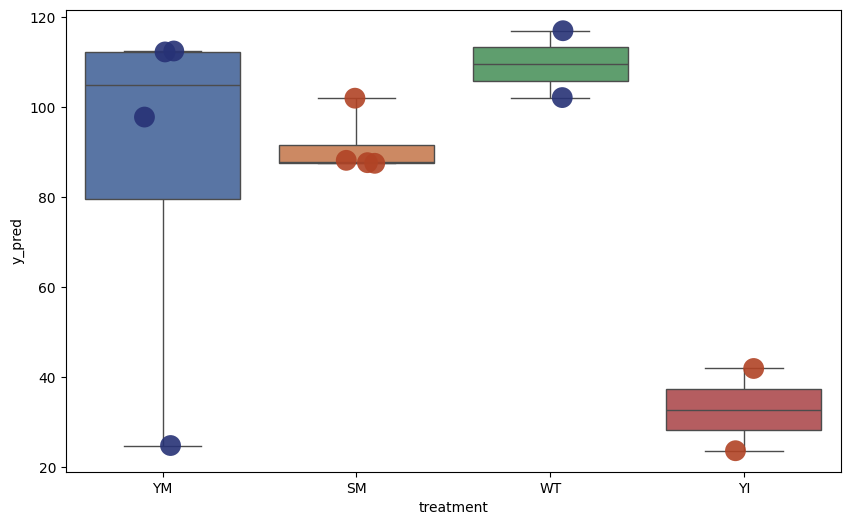

Components: 43
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   23.948627        YM  16wk
D13.YM.16wk.1   97.594559        YM  16wk
C19.SM.16wk.1   85.416541        SM  16wk
C12.SM.16wk.6   88.532318        SM  16wk
C11.SM.16wk.5  103.327884        SM  16wk
C10.SM.16wk.2   85.397420        SM  16wk
D16.YM.16wk.8  113.394341        YM  16wk
D14.YM.16wk.4  112.972053        YM  16wk
B8.WT.16wk.7   102.221123        WT  16wk
B6.WT.16wk.2   116.144801        WT  16wk
A18.YI.6wk.4    24.264852        YI   6wk
A17.YI.6wk.2    40.884384        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


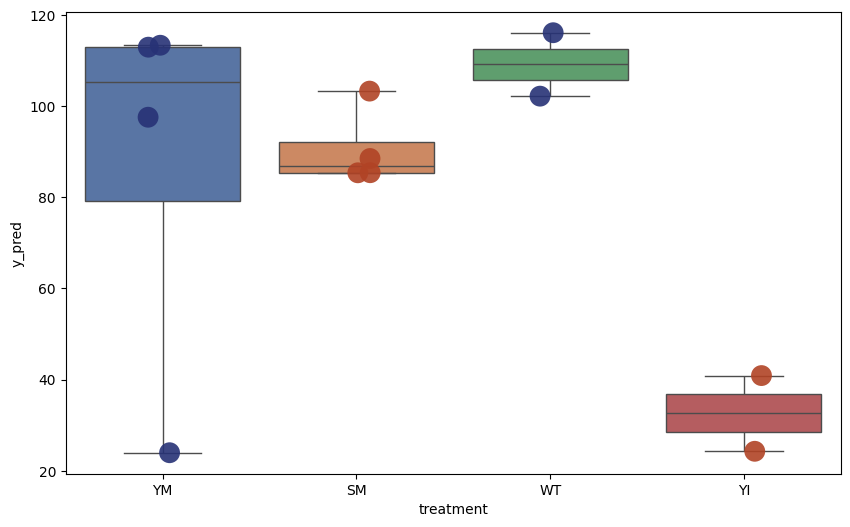

Components: 44
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   21.431623        YM  16wk
D13.YM.16wk.1   96.660349        YM  16wk
C19.SM.16wk.1   84.119553        SM  16wk
C12.SM.16wk.6   88.287951        SM  16wk
C11.SM.16wk.5  101.697060        SM  16wk
C10.SM.16wk.2   83.297880        SM  16wk
D16.YM.16wk.8  111.619731        YM  16wk
D14.YM.16wk.4  113.355822        YM  16wk
B8.WT.16wk.7   100.841806        WT  16wk
B6.WT.16wk.2   115.652157        WT  16wk
A18.YI.6wk.4    25.198473        YI   6wk
A17.YI.6wk.2    41.821345        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


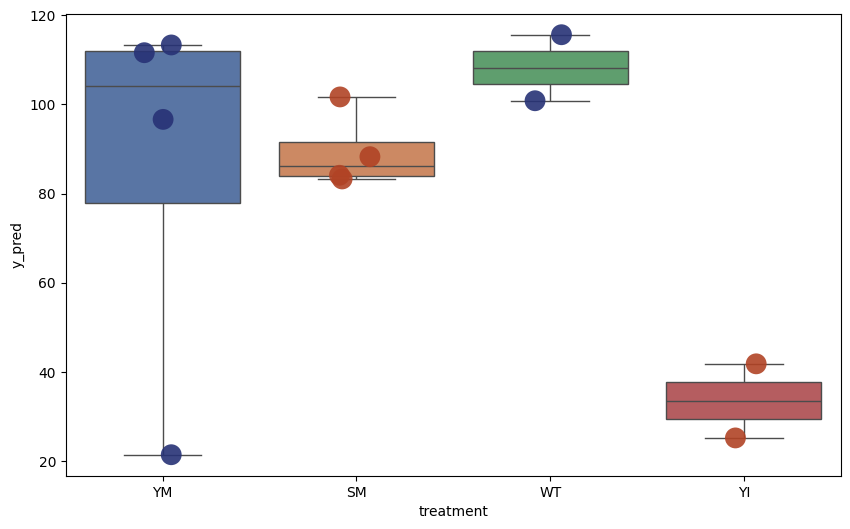

Components: 45
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   28.946456        YM  16wk
D13.YM.16wk.1   96.062832        YM  16wk
C19.SM.16wk.1   85.874345        SM  16wk
C12.SM.16wk.6   88.829685        SM  16wk
C11.SM.16wk.5  101.187181        SM  16wk
C10.SM.16wk.2   85.101411        SM  16wk
D16.YM.16wk.8  111.667926        YM  16wk
D14.YM.16wk.4  113.542680        YM  16wk
B8.WT.16wk.7   100.774111        WT  16wk
B6.WT.16wk.2   115.720896        WT  16wk
A18.YI.6wk.4    27.116223        YI   6wk
A17.YI.6wk.2    42.939603        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


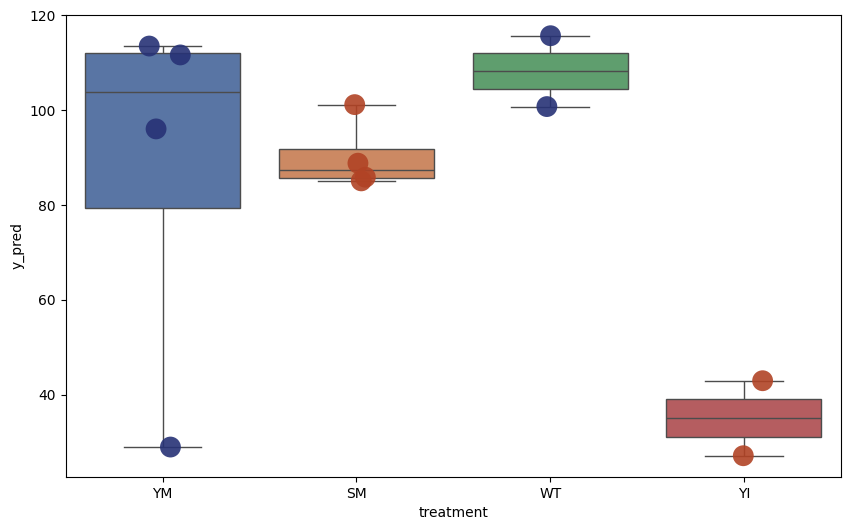

Components: 46
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   28.194733        YM  16wk
D13.YM.16wk.1   97.146417        YM  16wk
C19.SM.16wk.1   85.799337        SM  16wk
C12.SM.16wk.6   89.049971        SM  16wk
C11.SM.16wk.5  101.647417        SM  16wk
C10.SM.16wk.2   85.274530        SM  16wk
D16.YM.16wk.8  111.605439        YM  16wk
D14.YM.16wk.4  113.386026        YM  16wk
B8.WT.16wk.7   100.781673        WT  16wk
B6.WT.16wk.2   115.587891        WT  16wk
A18.YI.6wk.4    27.131294        YI   6wk
A17.YI.6wk.2    42.402309        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


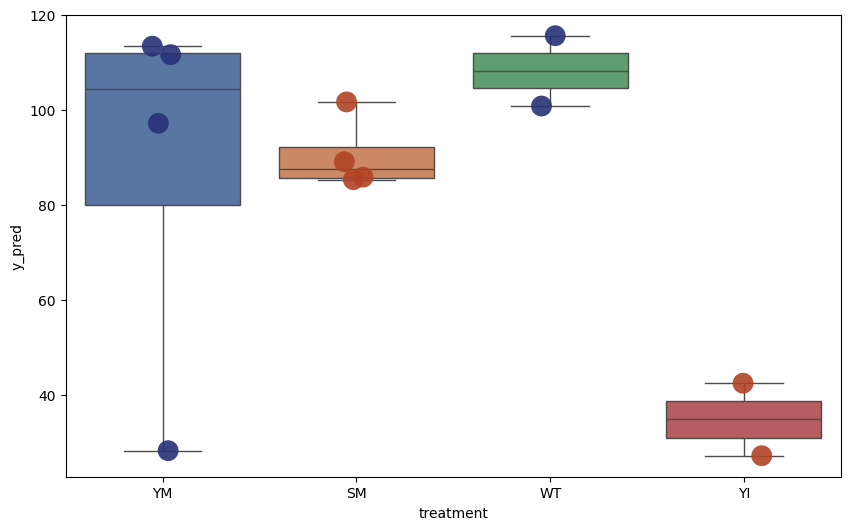

Components: 47
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   29.058280        YM  16wk
D13.YM.16wk.1   97.015473        YM  16wk
C19.SM.16wk.1   85.106866        SM  16wk
C12.SM.16wk.6   88.910116        SM  16wk
C11.SM.16wk.5  101.829771        SM  16wk
C10.SM.16wk.2   84.580693        SM  16wk
D16.YM.16wk.8  111.699873        YM  16wk
D14.YM.16wk.4  114.394430        YM  16wk
B8.WT.16wk.7   101.405899        WT  16wk
B6.WT.16wk.2   115.540864        WT  16wk
A18.YI.6wk.4    24.412886        YI   6wk
A17.YI.6wk.2    42.459936        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


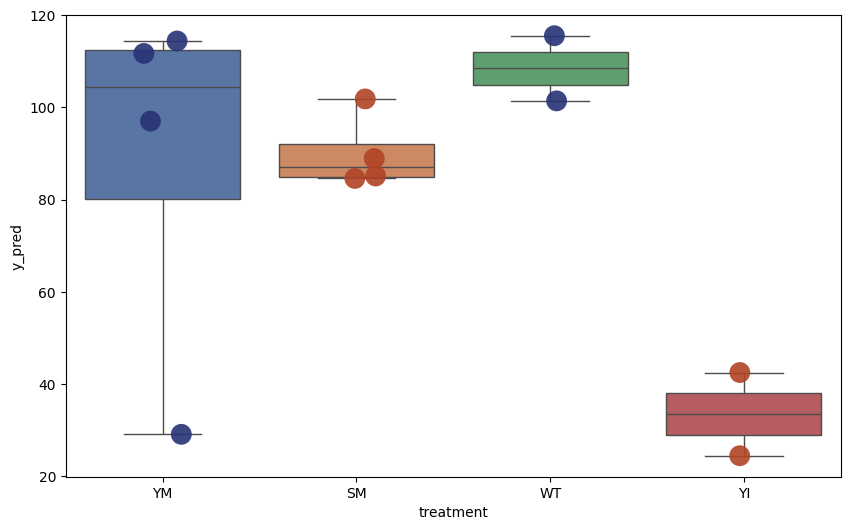

Components: 48
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   29.042713        YM  16wk
D13.YM.16wk.1   96.473713        YM  16wk
C19.SM.16wk.1   85.646577        SM  16wk
C12.SM.16wk.6   88.987333        SM  16wk
C11.SM.16wk.5  101.555699        SM  16wk
C10.SM.16wk.2   85.042399        SM  16wk
D16.YM.16wk.8  111.692765        YM  16wk
D14.YM.16wk.4  113.200956        YM  16wk
B8.WT.16wk.7   100.946663        WT  16wk
B6.WT.16wk.2   115.722732        WT  16wk
A18.YI.6wk.4    26.493715        YI   6wk
A17.YI.6wk.2    42.401931        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


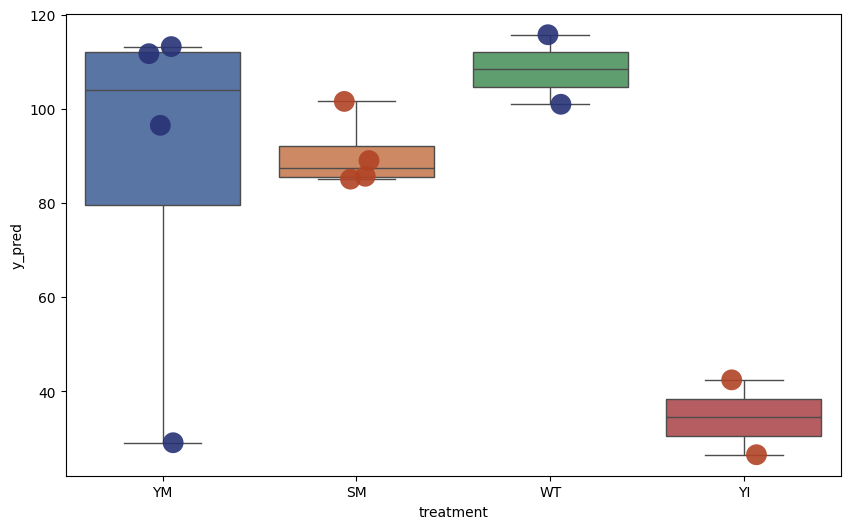

Components: 49
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   29.656194        YM  16wk
D13.YM.16wk.1   96.882362        YM  16wk
C19.SM.16wk.1   85.730516        SM  16wk
C12.SM.16wk.6   88.974663        SM  16wk
C11.SM.16wk.5  101.469563        SM  16wk
C10.SM.16wk.2   85.186719        SM  16wk
D16.YM.16wk.8  111.555772        YM  16wk
D14.YM.16wk.4  113.154755        YM  16wk
B8.WT.16wk.7   100.954208        WT  16wk
B6.WT.16wk.2   115.658115        WT  16wk
A18.YI.6wk.4    26.477320        YI   6wk
A17.YI.6wk.2    42.441453        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


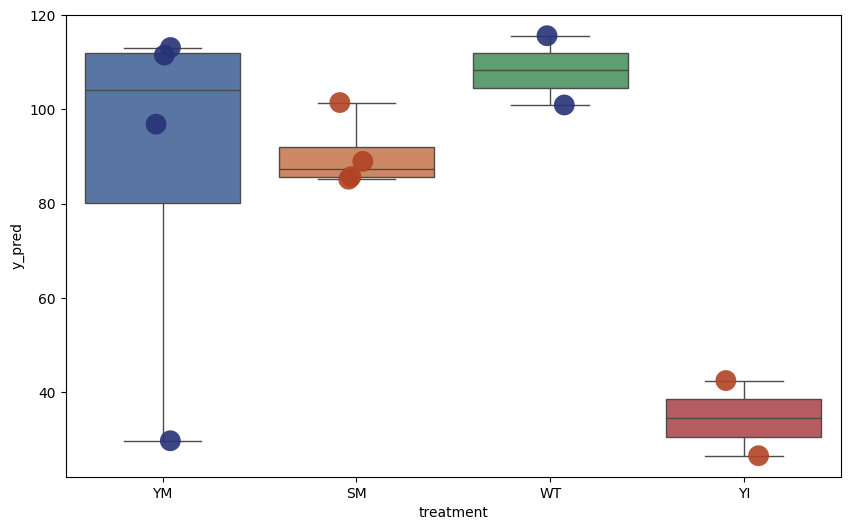

Components: 50
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   23.990418        YM  16wk
D13.YM.16wk.1   96.110645        YM  16wk
C19.SM.16wk.1   87.083954        SM  16wk
C12.SM.16wk.6   88.242022        SM  16wk
C11.SM.16wk.5   99.809572        SM  16wk
C10.SM.16wk.2   86.580338        SM  16wk
D16.YM.16wk.8  111.912821        YM  16wk
D14.YM.16wk.4  112.287756        YM  16wk
B8.WT.16wk.7   101.978875        WT  16wk
B6.WT.16wk.2   115.074243        WT  16wk
A18.YI.6wk.4    30.903022        YI   6wk
A17.YI.6wk.2    43.048035        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


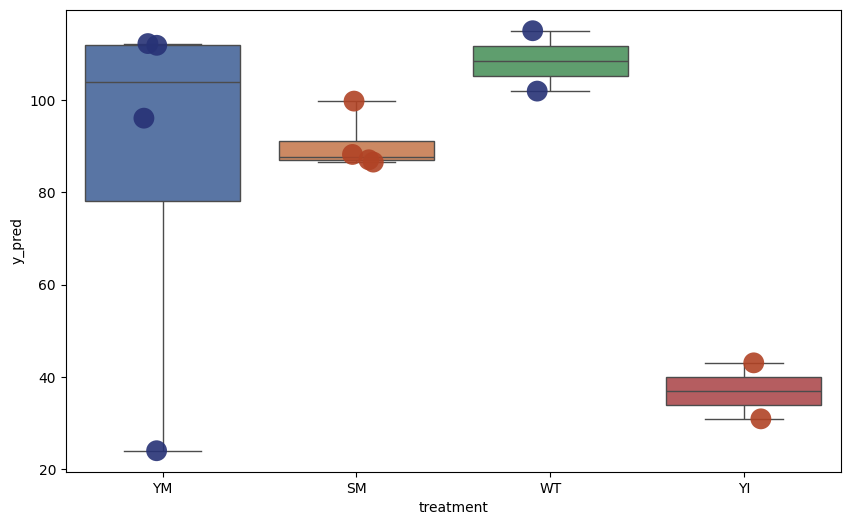

Components: 51
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   24.720638        YM  16wk
D13.YM.16wk.1   96.124151        YM  16wk
C19.SM.16wk.1   87.265892        SM  16wk
C12.SM.16wk.6   88.369574        SM  16wk
C11.SM.16wk.5  100.081420        SM  16wk
C10.SM.16wk.2   86.793916        SM  16wk
D16.YM.16wk.8  112.195355        YM  16wk
D14.YM.16wk.4  112.849694        YM  16wk
B8.WT.16wk.7   102.263250        WT  16wk
B6.WT.16wk.2   114.994203        WT  16wk
A18.YI.6wk.4    30.307194        YI   6wk
A17.YI.6wk.2    43.131543        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


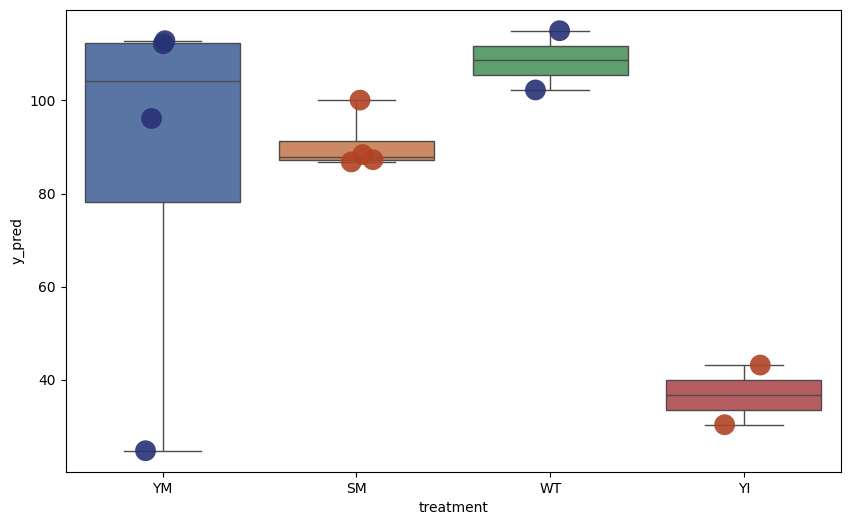

Components: 52
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   24.781794        YM  16wk
D13.YM.16wk.1   96.128826        YM  16wk
C19.SM.16wk.1   87.240288        SM  16wk
C12.SM.16wk.6   88.333442        SM  16wk
C11.SM.16wk.5  100.041537        SM  16wk
C10.SM.16wk.2   86.735873        SM  16wk
D16.YM.16wk.8  112.145384        YM  16wk
D14.YM.16wk.4  112.731148        YM  16wk
B8.WT.16wk.7   102.262610        WT  16wk
B6.WT.16wk.2   115.058802        WT  16wk
A18.YI.6wk.4    30.562820        YI   6wk
A17.YI.6wk.2    43.129447        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


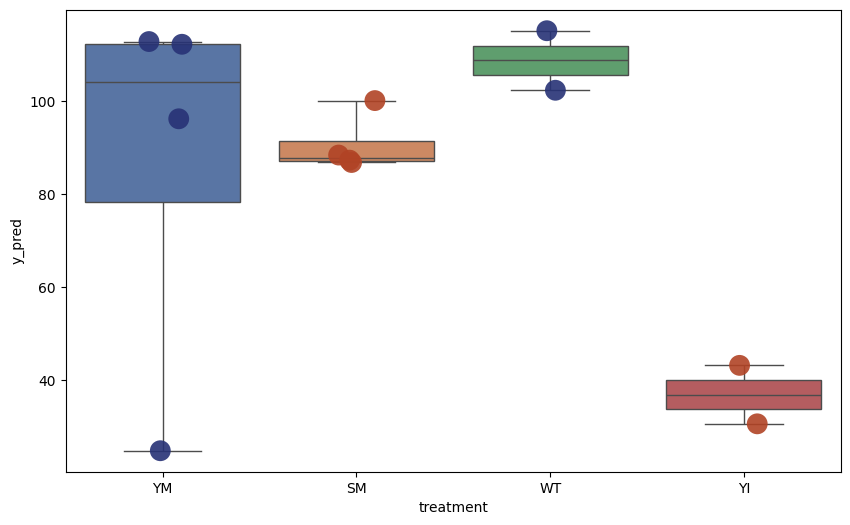

Components: 53
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   23.541792        YM  16wk
D13.YM.16wk.1   96.706353        YM  16wk
C19.SM.16wk.1   87.608984        SM  16wk
C12.SM.16wk.6   88.128850        SM  16wk
C11.SM.16wk.5  100.352140        SM  16wk
C10.SM.16wk.2   87.152882        SM  16wk
D16.YM.16wk.8  112.215090        YM  16wk
D14.YM.16wk.4  112.970551        YM  16wk
B8.WT.16wk.7   102.331466        WT  16wk
B6.WT.16wk.2   115.343440        WT  16wk
A18.YI.6wk.4    31.086988        YI   6wk
A17.YI.6wk.2    43.011163        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


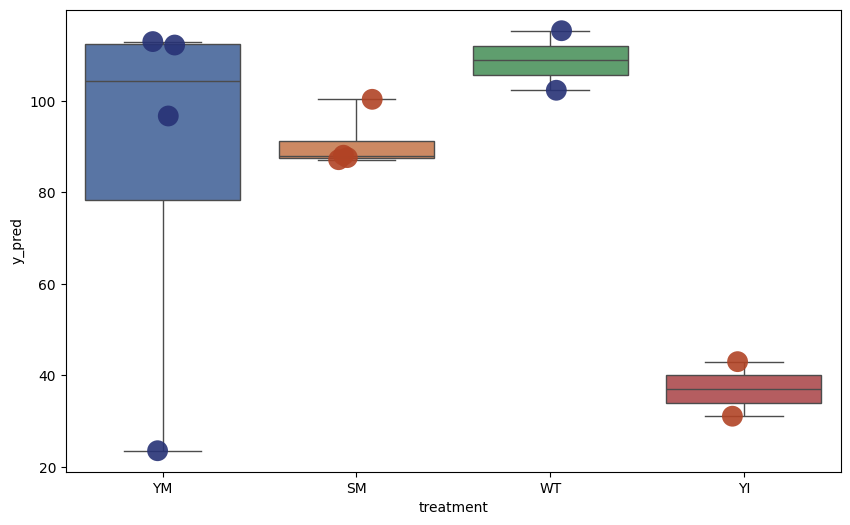

Components: 54
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   23.901267        YM  16wk
D13.YM.16wk.1   96.653375        YM  16wk
C19.SM.16wk.1   87.589352        SM  16wk
C12.SM.16wk.6   88.065023        SM  16wk
C11.SM.16wk.5  100.289124        SM  16wk
C10.SM.16wk.2   87.172251        SM  16wk
D16.YM.16wk.8  112.228127        YM  16wk
D14.YM.16wk.4  112.941440        YM  16wk
B8.WT.16wk.7   102.315399        WT  16wk
B6.WT.16wk.2   115.363462        WT  16wk
A18.YI.6wk.4    30.975806        YI   6wk
A17.YI.6wk.2    43.005911        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


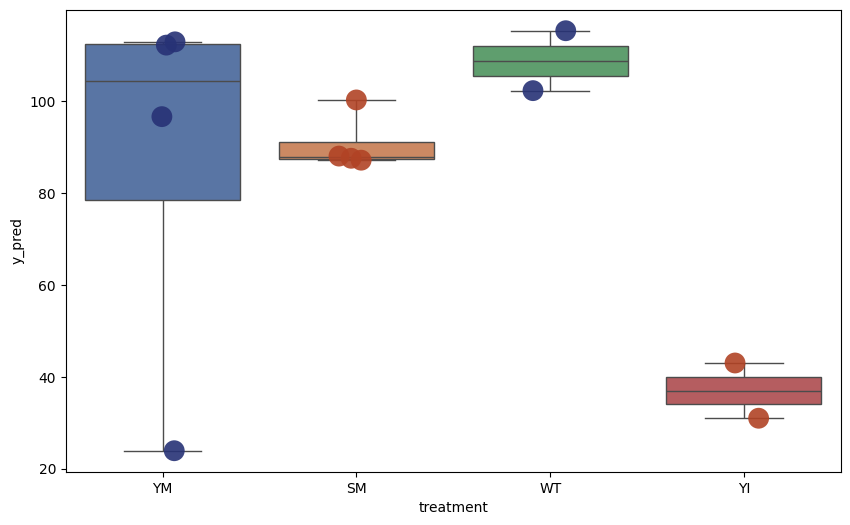

Components: 55
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   26.398692        YM  16wk
D13.YM.16wk.1   96.910089        YM  16wk
C19.SM.16wk.1   87.521915        SM  16wk
C12.SM.16wk.6   88.226441        SM  16wk
C11.SM.16wk.5  100.588647        SM  16wk
C10.SM.16wk.2   86.868374        SM  16wk
D16.YM.16wk.8  111.858624        YM  16wk
D14.YM.16wk.4  112.980625        YM  16wk
B8.WT.16wk.7   102.556033        WT  16wk
B6.WT.16wk.2   115.862314        WT  16wk
A18.YI.6wk.4    30.963418        YI   6wk
A17.YI.6wk.2    42.537441        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


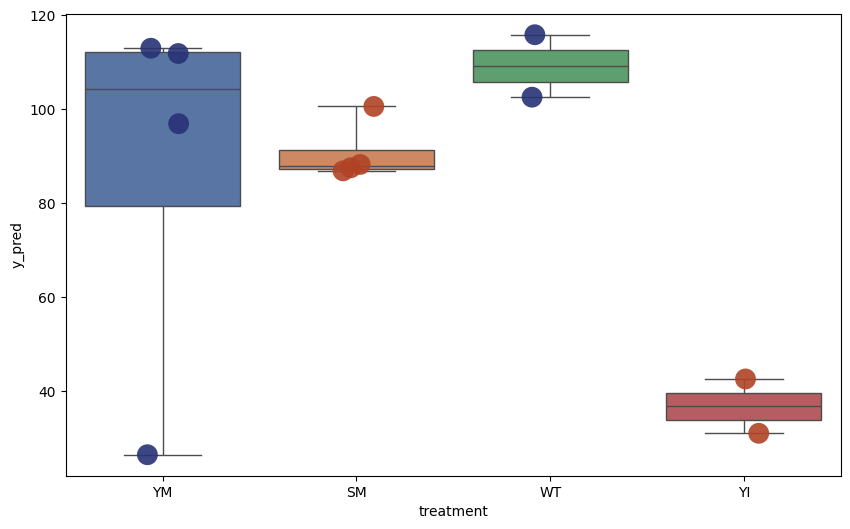

Components: 56
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   25.356834        YM  16wk
D13.YM.16wk.1   96.735129        YM  16wk
C19.SM.16wk.1   87.489280        SM  16wk
C12.SM.16wk.6   88.275240        SM  16wk
C11.SM.16wk.5  100.579259        SM  16wk
C10.SM.16wk.2   86.878615        SM  16wk
D16.YM.16wk.8  111.890799        YM  16wk
D14.YM.16wk.4  112.839453        YM  16wk
B8.WT.16wk.7   102.632064        WT  16wk
B6.WT.16wk.2   115.867578        WT  16wk
A18.YI.6wk.4    31.071118        YI   6wk
A17.YI.6wk.2    42.434623        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


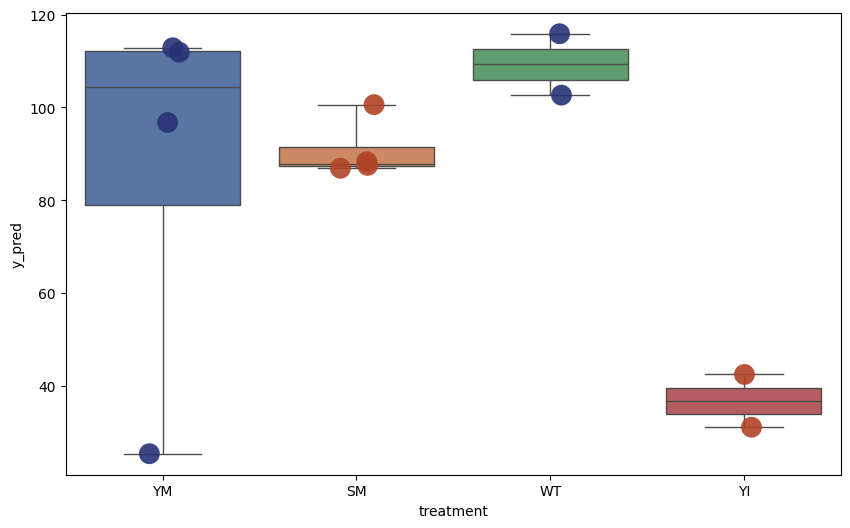

Components: 57
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   24.615137        YM  16wk
D13.YM.16wk.1   96.398264        YM  16wk
C19.SM.16wk.1   87.837376        SM  16wk
C12.SM.16wk.6   88.205313        SM  16wk
C11.SM.16wk.5  100.368322        SM  16wk
C10.SM.16wk.2   87.489373        SM  16wk
D16.YM.16wk.8  111.653681        YM  16wk
D14.YM.16wk.4  112.295063        YM  16wk
B8.WT.16wk.7   102.449190        WT  16wk
B6.WT.16wk.2   115.997438        WT  16wk
A18.YI.6wk.4    31.052269        YI   6wk
A17.YI.6wk.2    42.232466        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


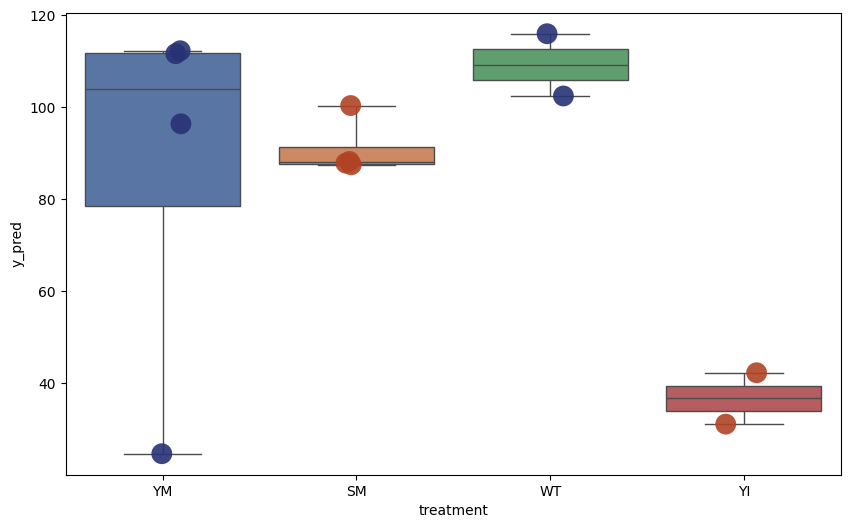

Components: 58
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   24.407255        YM  16wk
D13.YM.16wk.1   96.261777        YM  16wk
C19.SM.16wk.1   87.878874        SM  16wk
C12.SM.16wk.6   88.183984        SM  16wk
C11.SM.16wk.5  100.366824        SM  16wk
C10.SM.16wk.2   87.559466        SM  16wk
D16.YM.16wk.8  111.685125        YM  16wk
D14.YM.16wk.4  112.461172        YM  16wk
B8.WT.16wk.7   102.447027        WT  16wk
B6.WT.16wk.2   116.056979        WT  16wk
A18.YI.6wk.4    30.834597        YI   6wk
A17.YI.6wk.2    42.255169        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


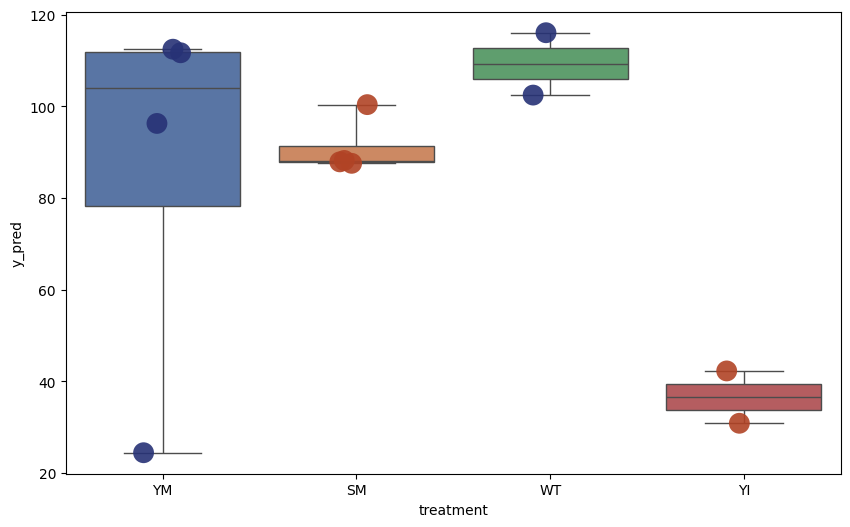

Components: 59
D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3   24.407255        YM  16wk
D13.YM.16wk.1   96.261777        YM  16wk
C19.SM.16wk.1   87.878874        SM  16wk
C12.SM.16wk.6   88.183984        SM  16wk
C11.SM.16wk.5  100.366824        SM  16wk
C10.SM.16wk.2   87.559466        SM  16wk
D16.YM.16wk.8  111.685125        YM  16wk
D14.YM.16wk.4  112.461172        YM  16wk
B8.WT.16wk.7   102.447027        WT  16wk
B6.WT.16wk.2   116.056979        WT  16wk
A18.YI.6wk.4    30.834597        YI   6wk
A17.YI.6wk.2    42.255169        YI   6wk


/tmp/ipython-input-2472249845.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
/tmp/ipython-input-2472249845.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(
/tmp/ipython-input-2472249845.py:48: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


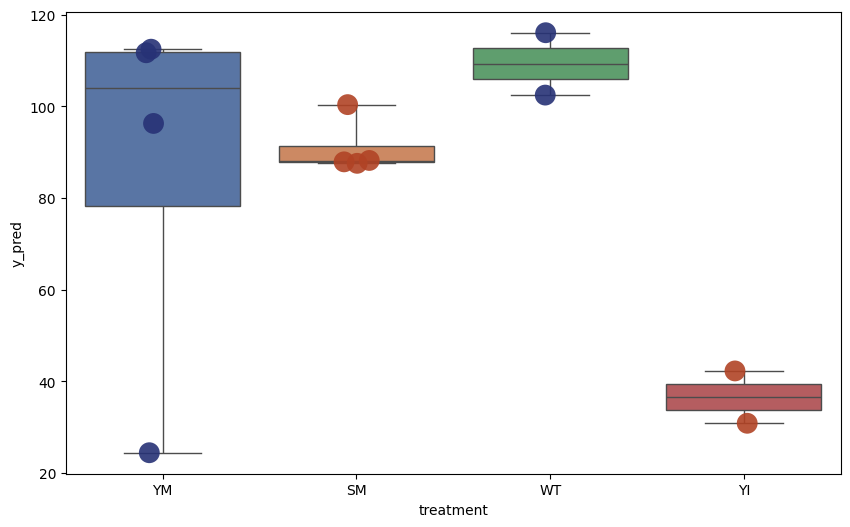

In [55]:
# Loop through all possible components to predict the test set
max_components = min(X_train_scaled.shape[0], X_train_scaled.shape[1])
all_y_test_preds = []

for n_components in range(1, max_components + 1):
    print(f"Components: {n_components}")

    # Apply PCA
    pca = PCA(n_components=n_components, svd_solver = 'full',random_state=1)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # Train the model
    regressor = LinearRegression()
    regressor.fit(X_train_pca, age_train)

    # Predict on the test set
    y_test_pred = regressor.predict(X_test_pca)

    # Save the actual and predicted values to a DataFrame
    results_df = pd.DataFrame({
    'y_pred': y_test_pred
    }, index=df_intervention_test.index.tolist()) # this should be the test dataset

    df_intervention = results_df.loc[df_intervention_test.index.tolist(), ]

    df_intervention.head(5)

    # Make sure index is treated as string
    sample_names = df_intervention.index.to_series().astype(str)

    print(sample_names)

    # Extract treatment (between first and second period)
    df_intervention["treatment"] = sample_names.str.extract(r'^[^.]+\.([^.]+)\.')

    # Extract age (between second and third period)
    df_intervention["age"] = sample_names.str.extract(r'^[^.]+\.[^.]+\.([^.]+)\.')

    print(df_intervention)

    # Create the box plot
    plt.figure(figsize=(10, 6))
    box = sns.boxplot(x='treatment', y='y_pred', data=df_intervention, palette='deep', showfliers = False, whis = [0,100])
    custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

    # Add data points with custom colors
    strip = sns.stripplot(
        x='treatment',
        y='y_pred',
        data=df_intervention,
        palette=custom_palette,  # Custom color palette
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=15
    )

    # # Show the plot
    plt.show()


##### Select PCA number, export to csv

In [59]:
n_components = 14

# Apply PCA
pca = PCA(n_components=n_components,svd_solver = 'full',random_state=1)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train the model
regressor = LinearRegression()
regressor.fit(X_train_pca, age_train)

# Predict on the test set
y_test_pred = regressor.predict(X_test_pca)

# Save the actual and predicted values to a DataFrame
results_df = pd.DataFrame({
'y_pred': y_test_pred
}, index=df_intervention_test.index.tolist()) # this should be the test dataset

df_intervention = results_df.loc[df_intervention_test.index.tolist(), ]

df_intervention.head(5)

# Make sure index is treated as string
sample_names = df_intervention.index.to_series().astype(str)

print(sample_names)

# Extract treatment (between first and second period)
df_intervention["treatment"] = sample_names.str.extract(r'^[^.]+\.([^.]+)\.')

# Extract age (between second and third period)
df_intervention["age"] = sample_names.str.extract(r'^[^.]+\.[^.]+\.([^.]+)\.')

print(df_intervention)
df_intervention.to_csv("./predictions/Smith_gut_sexcombo_predictions_14PCs_EC-250723.csv")


D15.YM.16wk.3    D15.YM.16wk.3
D13.YM.16wk.1    D13.YM.16wk.1
C19.SM.16wk.1    C19.SM.16wk.1
C12.SM.16wk.6    C12.SM.16wk.6
C11.SM.16wk.5    C11.SM.16wk.5
C10.SM.16wk.2    C10.SM.16wk.2
D16.YM.16wk.8    D16.YM.16wk.8
D14.YM.16wk.4    D14.YM.16wk.4
B8.WT.16wk.7      B8.WT.16wk.7
B6.WT.16wk.2      B6.WT.16wk.2
A18.YI.6wk.4      A18.YI.6wk.4
A17.YI.6wk.2      A17.YI.6wk.2
dtype: object
                   y_pred treatment   age
D15.YM.16wk.3    3.423919        YM  16wk
D13.YM.16wk.1  100.368279        YM  16wk
C19.SM.16wk.1   82.291811        SM  16wk
C12.SM.16wk.6   84.828877        SM  16wk
C11.SM.16wk.5   94.228590        SM  16wk
C10.SM.16wk.2   81.138321        SM  16wk
D16.YM.16wk.8  110.297578        YM  16wk
D14.YM.16wk.4  107.969990        YM  16wk
B8.WT.16wk.7    98.160099        WT  16wk
B6.WT.16wk.2   112.931351        WT  16wk
A18.YI.6wk.4     7.804137        YI   6wk
A17.YI.6wk.2    39.291536        YI   6wk


# Rotating training samples

In [60]:
# --------------------------------------------------------------------
# Config
# --------------------------------------------------------------------
OUTDIR = "./predictions_exhaustive"
os.makedirs(OUTDIR, exist_ok=True)

# If you want to cap PCs to a smaller number (e.g., 100), set here; else leave None to use full allowable range
PC_CAP = 20   # e.g., PC_CAP = 100

# --------------------------------------------------------------------
# Sample selection setup (same as your BayesAge loop)
# --------------------------------------------------------------------
WT_samples = df_intervention_age[df_intervention_age['training'] == 'Yes'].index

# Separate the samples
young_samples = [s for s in WT_samples if '.6wk' in s.lower()]
old_samples = [s for s in WT_samples if '.16wk' in s.lower()]

# All 2x2 combinations
young_combos = list(itertools.combinations(young_samples, 2))
old_combos   = list(itertools.combinations(old_samples, 2))

In [61]:
df_intervention_age.head(1)

Sample.Name,cnot8,LOC107386976,LOC107379175,inhbb,LOC107372844,LOC107391735,dhdds,LOC107384934,LOC107375999,LOC107396709,...,barx2,fbxl6,rtca,LOC107388120,tissue,AGE,sex,training,treatment,age
D15.YM.16wk.3,509.104136,195.809283,203.340409,237.98359,48.199208,280.157897,192.796833,15750.597485,55.730334,10766.498119,...,3.012451,387.09989,176.228355,90.373515,Gut,16 weeks,male,No,YM.16wk.3,112


In [65]:
random.seed(123)
# --------------------------------------------------------------------
# Main loop: iterate over all combos, then sweep PC numbers
# --------------------------------------------------------------------
for y_combo in young_combos:
    for o_combo in old_combos:

        combo_id = f"{'_'.join(map(str, y_combo))}__{'_'.join(map(str, o_combo))}"
        print(f"\nRunning PCR for combo: {combo_id}")

        # ----------------------------
        # Build TRAIN/ATLAS combined
        # ----------------------------
        select_train_samples = list(y_combo) + list(o_combo)

        df_intervention_train_full = df_intervention_age.loc[select_train_samples]

        # Use tissue_df_age (counts + age + meta) for atlas, then append intervention rows
        atlas_plus_intervention = pd.concat([tissue_df_age, df_intervention_train_full], axis=0)

        # Age target (pull BEFORE dropping meta columns)
        y_train_age = atlas_plus_intervention['age'].astype(float)

        # Training features: drop metadata columns by your index pattern
        X_train_counts = atlas_plus_intervention.drop(
            atlas_plus_intervention.columns[[-1,-2, -3, -4, -5, -6]], axis=1
        )

        # ----------------------------
        # Build TEST matrices/metadata
        # ----------------------------
        test_samples = [s for s in df_intervention_age.index if s not in select_train_samples]
        df_intervention_test_full = df_intervention_age.loc[test_samples]

        # Drop the same metadata columns for TEST and align to train columns
        X_test_counts = df_intervention_test_full.drop(
            df_intervention_test_full.columns[[-1,-2, -3, -4,-5, -6]], axis=1
        )
        X_test_counts = X_test_counts[X_train_counts.columns]

        # build dataframe
        test_samples = pd.Series(test_samples)
        test_meta = pd.DataFrame(index=test_samples)

        # Extract treatment (between first and second period)
        test_meta["treatment"] = test_samples.str.extract(r'^[^.]+\.([^.]+)\.')

        # Extract age (between second and third period)
        test_meta["age"] = test_samples.str.extract(r'^[^.]+\.[^.]+\.([^.]+)\.')

        # ----------------------------
        # Scale and PCR
        # ----------------------------
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_counts.values)
        X_test_scaled  = scaler.transform(X_test_counts.values)

        # Determine allowable PCs
        max_components_allowed = min(X_train_scaled.shape[0], X_train_scaled.shape[1])
        if PC_CAP is not None:
            max_components_allowed = min(max_components_allowed, PC_CAP)

        for n_components in range(1, max_components_allowed + 1):
            print(f"  PCs: {n_components}")

            # PCA on training, transform both
            pca = PCA(n_components=n_components,svd_solver = 'full', random_state=1)
            X_train_pca = pca.fit_transform(X_train_scaled)
            X_test_pca  = pca.transform(X_test_scaled)

            # Linear regression on PCs → age
            regressor = LinearRegression()
            regressor.fit(X_train_pca, y_train_age.values)

            # Predict for test samples
            y_test_pred = regressor.predict(X_test_pca)

            # Package output with metadata
            df_pred = pd.DataFrame({'y_pred': y_test_pred}, index=test_samples)
            df_pred = df_pred.join(test_meta, how='left').sort_values(by="age")

            # Save
            out_prefix = f"PCR_pred_{combo_id}_pc{n_components:03d}"
            out_path = os.path.join(OUTDIR, f"{out_prefix}.tsv")
            df_pred.to_csv(out_path, sep="\t")



Running PCR for combo: A3.YI.6wk.3_A2.YI.6wk.1__B7.WT.16wk.6_B5.WT.16wk.1
  PCs: 1
  PCs: 2
  PCs: 3
  PCs: 4
  PCs: 5
  PCs: 6
  PCs: 7
  PCs: 8
  PCs: 9
  PCs: 10
  PCs: 11
  PCs: 12
  PCs: 13
  PCs: 14
  PCs: 15
  PCs: 16
  PCs: 17
  PCs: 18
  PCs: 19
  PCs: 20

Running PCR for combo: A3.YI.6wk.3_A2.YI.6wk.1__B7.WT.16wk.6_B8.WT.16wk.7
  PCs: 1
  PCs: 2
  PCs: 3
  PCs: 4
  PCs: 5
  PCs: 6
  PCs: 7
  PCs: 8
  PCs: 9
  PCs: 10
  PCs: 11
  PCs: 12
  PCs: 13
  PCs: 14
  PCs: 15
  PCs: 16
  PCs: 17
  PCs: 18
  PCs: 19
  PCs: 20

Running PCR for combo: A3.YI.6wk.3_A2.YI.6wk.1__B7.WT.16wk.6_B6.WT.16wk.2
  PCs: 1
  PCs: 2
  PCs: 3
  PCs: 4
  PCs: 5
  PCs: 6
  PCs: 7
  PCs: 8
  PCs: 9
  PCs: 10
  PCs: 11
  PCs: 12
  PCs: 13
  PCs: 14
  PCs: 15
  PCs: 16
  PCs: 17
  PCs: 18
  PCs: 19
  PCs: 20

Running PCR for combo: A3.YI.6wk.3_A2.YI.6wk.1__B5.WT.16wk.1_B8.WT.16wk.7
  PCs: 1
  PCs: 2
  PCs: 3
  PCs: 4
  PCs: 5
  PCs: 6
  PCs: 7
  PCs: 8
  PCs: 9
  PCs: 10
  PCs: 11
  PCs: 12
  PCs: 13
  PCs: